[saved] band_diagram_20260312_155310.svg


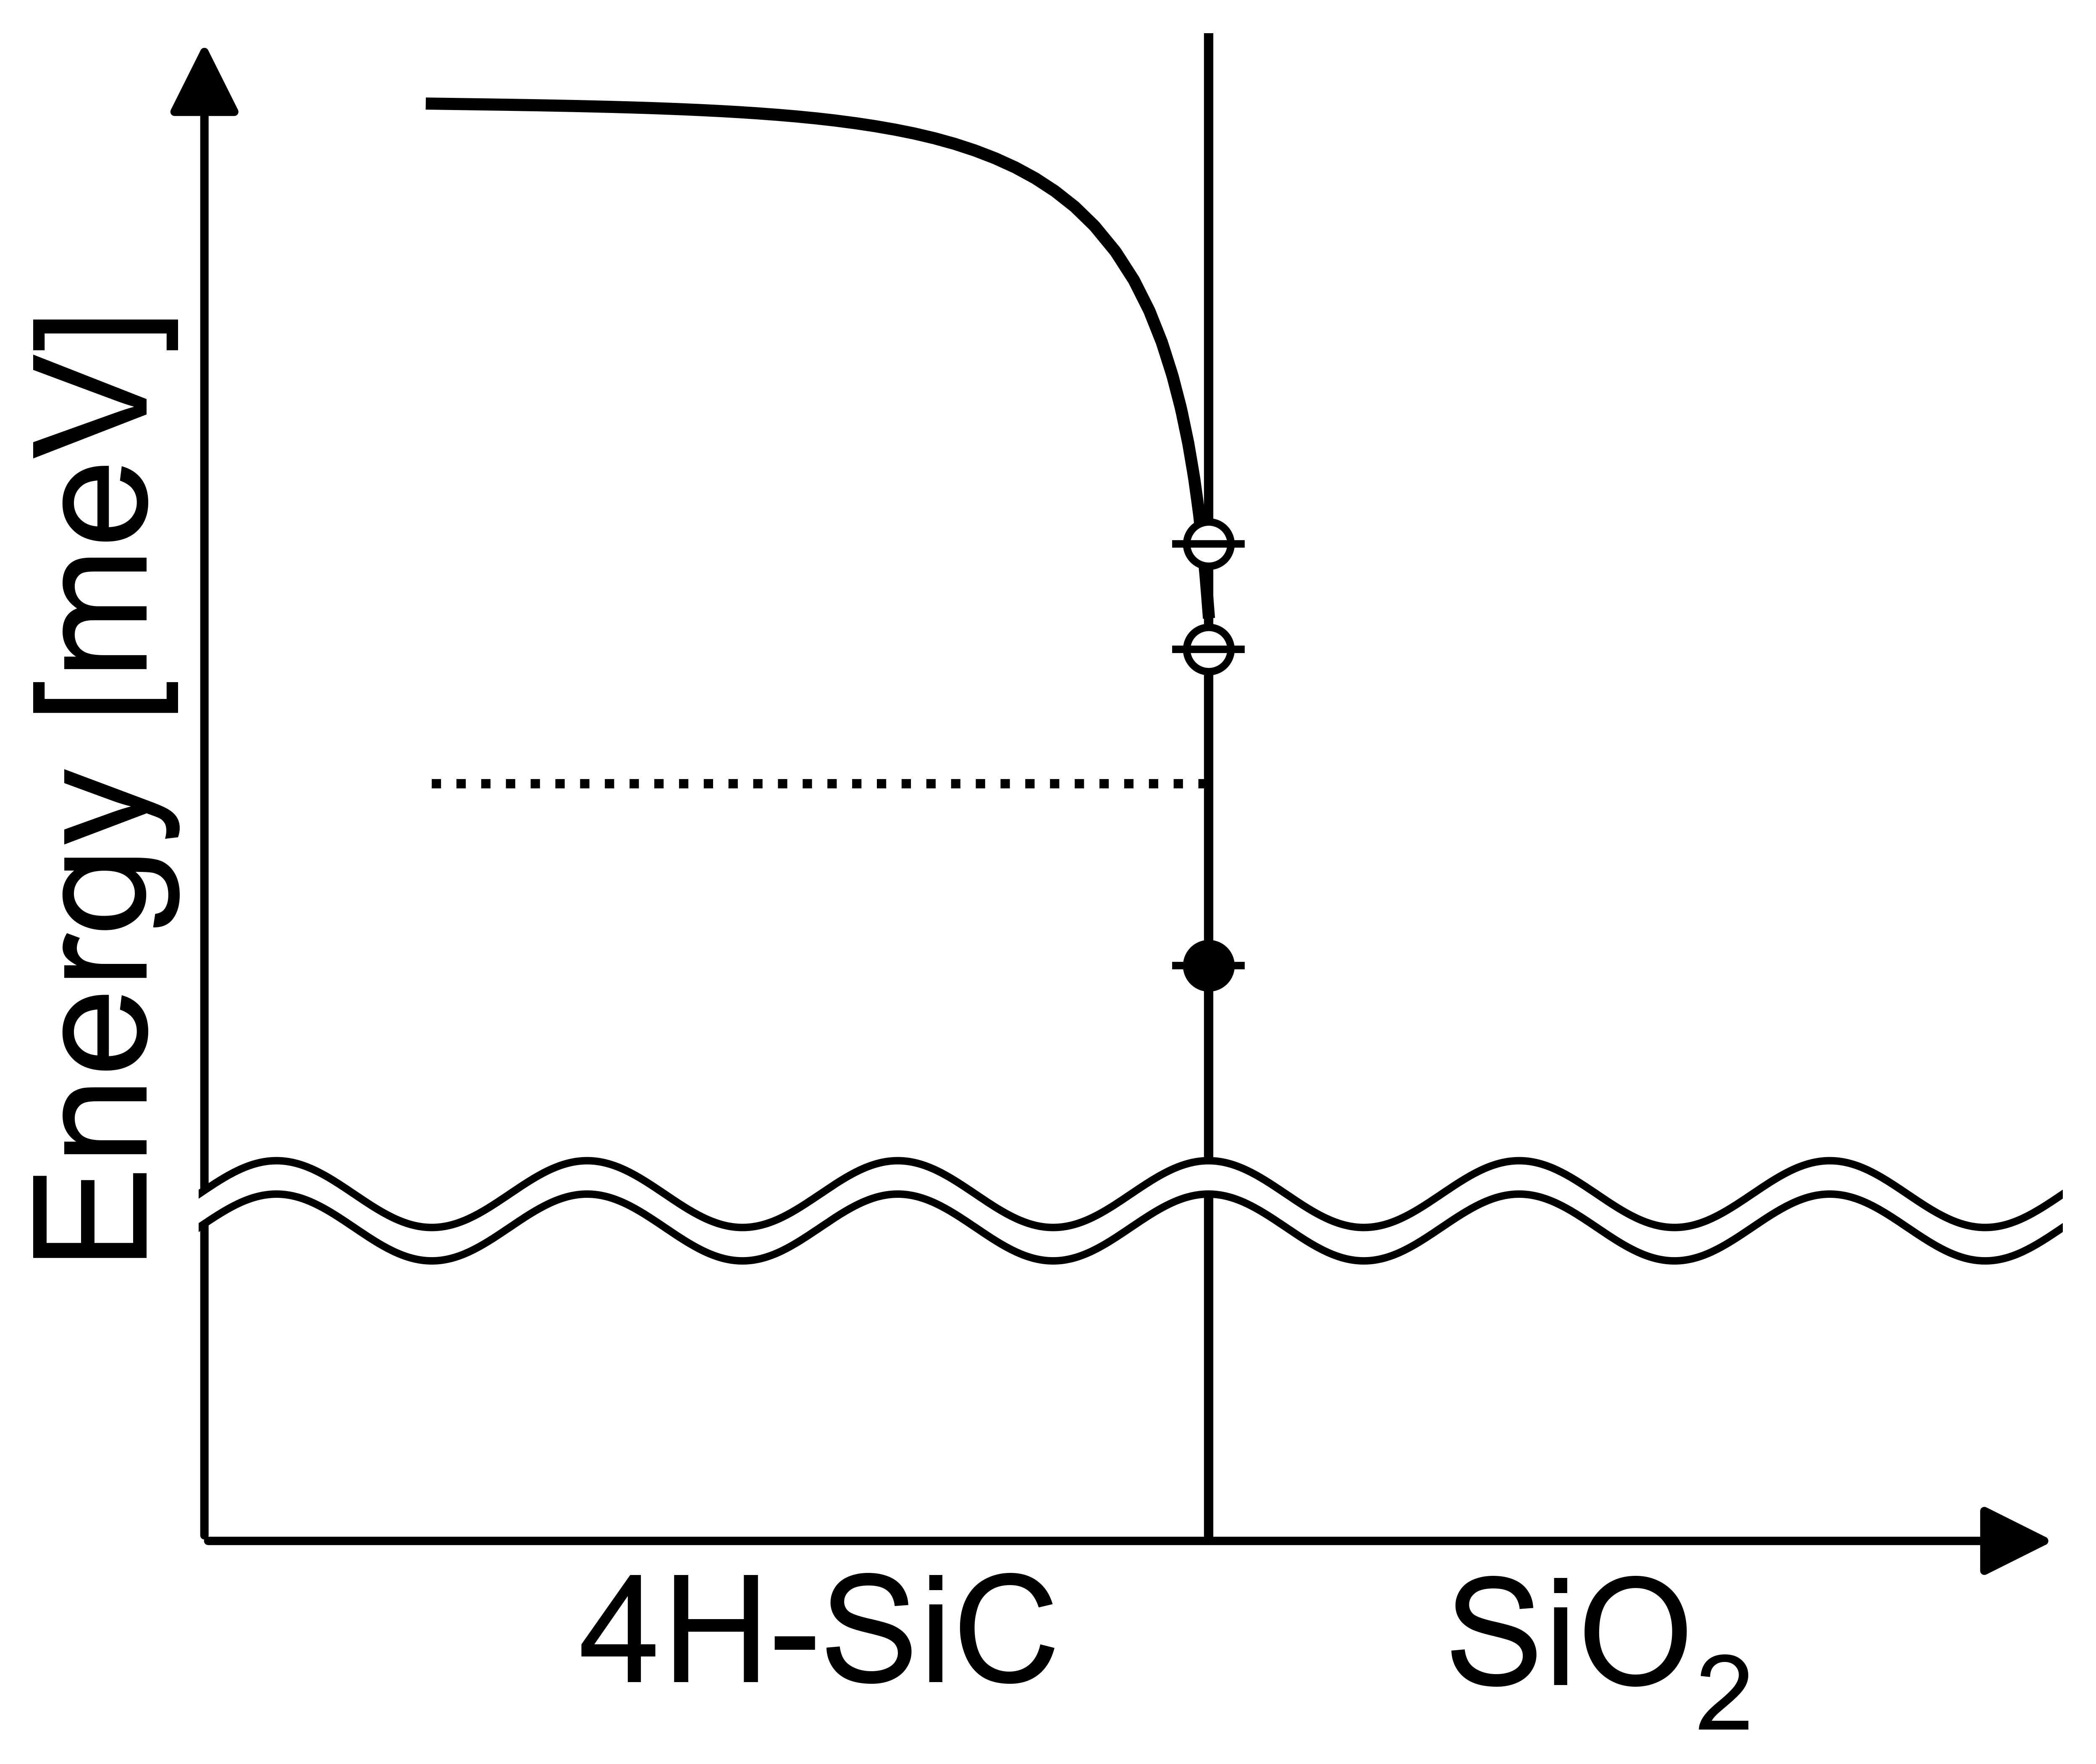

In [ ]:
# -*- coding: utf-8 -*-
"""
Band diagram generator
- SiC band bending can be drawn either
  (A) from manual analytical BandBending parameters, or
  (B) from ALLNODES.csv (r≈0, z<0 vertical potential profile).

ALLNODES.csv format expected:
    x (nm), y (nm), u (V)
where
    x = signed radius r [nm]
    y = z [nm]
    u = electrostatic potential [V]

Main update:
- If cfg.band_profile.use_allnodes_profile = True,
  the SiC-side Ec/Ev/Evac are drawn using the potential profile
  extracted from ALLNODES.csv at r≈0 and z<0.
- Other parameters (Ef, Ec bulk position, Ev bulk position, Evac, oxide top, ...)
  remain manually specified as before.
"""

from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams


# ---- Fonts ----
rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "mathtext.sf": "Arial",
    "mathtext.tt": "Arial",
    "mathtext.cal": "Arial",
    "axes.unicode_minus": False,
})

# ======================= 1) Data models =======================

@dataclass
class TrapLevel:
    energy_eV: float
    label: str = ""
    region: str = "interface"   # "sic" | "interface" | "oxide" | "tip"
    x_offset: float = 1.0
    marker_size: int = 90


@dataclass
class BandBending:
    # manual / legacy mode
    delta_Ec_surface_eV: float = 0.0
    delta_Ev_surface_eV: float = 0.0
    curvature: float = 2.0
    use_exponential: bool = False
    lambda_len: float = 0.35


@dataclass
class AllNodesProfileConfig:
    use_allnodes_profile: bool = False
    csv_path: str = "ALLNODES.csv"

    # extract r ~ 0 vertical line
    r_target_nm: float = 0.0
    r_tol_nm: float = 1e-6

    # use only z < 0 (inside sample side)
    z_max_nm: float = -1e-9   # practically z < 0
    z_min_nm: Optional[float] = None

    # mapping from z profile -> drawing x profile
    # z=0 (interface) should correspond to the right edge of SiC (x1)
    # deeper z corresponds to leftward direction
    flip_depth_direction: bool = True

    # potential-to-band conversion:
    # band shift = -(u(z)-u_bulk_ref)
    # for electron energy bands
    # If potential becomes more negative near surface, this gives upward/downward bend accordingly.
    subtract_bulk_reference: bool = True

    # bulk reference position in z-profile:
    # use deepest point if True, else use explicit z
    use_deepest_as_bulk_ref: bool = True
    bulk_ref_z_nm: Optional[float] = None

    # optional smoothing
    smooth_window: int = 1  # odd integer; 1 means no smoothing

    # interpolation points for plotting
    n_interp: int = 500


@dataclass
class RegionWidths:
    sic: float = 4.0
    oxide: float = 0.9
    gap: float = 3.0
    tip: float = 1.0


@dataclass
class LabelOffsets:
    Ec_tag: Tuple[float, float] = (0.06,  0.02)
    Ev_tag: Tuple[float, float] = (0.06, -0.04)
    Ef_tag: Tuple[float, float] = (0.06,  0.02)
    Evac_dy: float = -0.03


@dataclass
class AxesArrowOptions:
    enabled: bool = True
    lw: float = 1.8
    head_width_pts: float = 8.0
    head_length_pts: float = 10.0
    origin_shift_frac: Tuple[float, float] = (0.0, 0.0)
    x_overshoot_frac: float = 0.0
    y_overshoot_frac: float = 0.0


@dataclass
class DiagramConfig:
    # Energies (manual base positions)
    Ev_bulk_eV: float
    Ec_bulk_eV: float
    Ef_sic_eV: float
    Ef_tip_eV: float
    Evac_eV: float

    # Plot range
    y_min_eV: float = 0.0
    y_max_eV: float = 6.0

    # Geometry
    widths: RegionWidths = field(default_factory=RegionWidths)
    show_oxide: bool = True
    sic_oxide_only: bool = False

    # SiO2 upper edge model
    oxide_top_eV: Optional[float] = None
    oxide_follow_scale: float = 1.0
    vacuum_follow_scale: float = 0.0  # unused

    # SiC band bending
    bending: BandBending = field(default_factory=BandBending)

    # NEW: ALLNODES-based band profile
    band_profile: AllNodesProfileConfig = field(default_factory=AllNodesProfileConfig)

    # Traps
    traps: List[TrapLevel] = field(default_factory=list)
    show_traps: bool = True

    # Style
    show_level_tags: bool = True
    label_offsets: LabelOffsets = field(default_factory=LabelOffsets)
    show_hatch_semifilled: bool = True
    figsize: Tuple[float, float] = (12.0, 6.2)
    dpi: int = 160
    fontsize: int = 16

    # Region labels
    region_label_sic: str = "4H-SiC"
    region_label_oxide: str = "SiO$_2$"
    region_label_vac: str = "Vac"
    region_label_tip: str = "Tip"
    region_label_y: float = 0.02
    show_region_labels: bool = True

    # Colors
    colors: Optional[Dict[str, str]] = None

    # Output
    output_path: Optional[object] = None  # None/False→no save, True/"auto"→timestamp, str→path

    # SiC region start
    sic_x_start: float = 0.0
    sic_curve_start_frac: float = 0.0   # used only in manual mode

    # Design tweaks
    ef_sic_extend_left_frac: float = 0.08
    left_blank_frac: float = 0.40

    # Axis arrows
    axes_arrow: AxesArrowOptions = field(default_factory=AxesArrowOptions)

    # Layout lock
    lock_layout: bool = True
    layout_gap_ref: Optional[float] = None
    layout_margin_frac: float = 0.05

    # Vacuum coupling (SiO2 mode)
    eps_oxide_rel: float = 3.9
    vacuum_model: str = "series"    # "series" or "exp"
    vacuum_L0: float = 1.0
    vacuum_coupling_scale: float = 1.0

    # Diamond mode flags
    draw_evac_in_solid: bool = False
    draw_evac_in_tip: bool = False
    show_tip: bool = True

    # Trap marker line
    trap_line_dx_frac: float = 0.012
    trap_line_lw: float = 1.6

    # Energy omission band
    energy_break_enabled: bool = False
    energy_break_range: Optional[Tuple[float, float]] = None
    energy_break_n_periods: float = 6.0
    energy_break_amplitude_frac: float = 0.35

    # 上下の波線の位置を edge からどれだけ内側へ寄せるかを、
    # break band height に対する割合で指定
    # 0.0 なら従来に近い、値を大きくすると2本の波線の間隔が狭くなる
    energy_break_edge_offset_frac: float = 0.25

    # 上下波線それぞれに追加の微調整を入れたい場合
    # 正なら band中心側へ移動、負なら端側へ移動
    energy_break_lower_offset_frac: float = 0.0
    energy_break_upper_offset_frac: float = 0.0
    
# ======================= 2) Utilities =======================

def _C(cfg: DiagramConfig, key: str, default_gray: str) -> str:
    return (cfg.colors or {}).get(key, default_gray)


def _shape_value(t: np.ndarray, curv: float, use_exp: bool, L: float) -> np.ndarray:
    t = np.clip(t, 0.0, 1.0)
    if use_exp:
        L = max(1e-9, L)
        s = 1.0 - np.exp(-t / L)
        s /= (1.0 - np.exp(-1.0 / L))
        return s
    return t ** max(1.0, curv)


def _auto_filename(prefix: str = "band_diagram", ext: str = "svg") -> str:
    return f"{prefix}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.{ext}"


def _draw_axis_arrows(ax, xmin, xmax, ymin, ymax, opts: AxesArrowOptions):
    xr = (xmax - xmin)
    yr = (ymax - ymin)
    ox = xmin + opts.origin_shift_frac[0] * xr
    oy = ymin + opts.origin_shift_frac[1] * yr
    x_start = xmin - opts.x_overshoot_frac * xr
    x_end   = xmax + opts.x_overshoot_frac * xr
    y_start = ymin - opts.y_overshoot_frac * yr
    y_end   = ymax + opts.y_overshoot_frac * yr

    ax.annotate(
        "", xy=(x_end, oy), xytext=(x_start, oy),
        arrowprops=dict(arrowstyle="-|>", lw=opts.lw, color="0.0"),
        clip_on=False
    )
    ax.annotate(
        "", xy=(ox, y_end), xytext=(ox, y_start),
        arrowprops=dict(arrowstyle="-|>", lw=opts.lw, color="0.0"),
        clip_on=False
    )


def _eta_gap(cfg: DiagramConfig, w: RegionWidths) -> float:
    """η(s): 0→weak coupling (far), 1→strong (near)."""
    s = max(0.0, float(w.gap))
    if s <= 1e-12:
        return 1.0
    if cfg.vacuum_model.lower() == "exp":
        L0 = max(1e-9, float(cfg.vacuum_L0))
        eta = np.exp(-s / L0)
    else:
        t_ox = max(1e-9, float(w.oxide if w.oxide > 0.0 else 1.0))
        eta = 1.0 / (1.0 + cfg.eps_oxide_rel * s / t_ox)
    return float(np.clip(eta, 0.0, 1.0))


def _draw_energy_break_band(ax, cfg: DiagramConfig, xmin: float, xmax: float):
    if (not cfg.energy_break_enabled) or (cfg.energy_break_range is None):
        return

    E_low, E_high = cfg.energy_break_range
    y0 = max(min(E_low, E_high), cfg.y_min_eV)
    y1 = min(max(E_low, E_high), cfg.y_max_eV)
    if y1 <= y0 + 1e-6:
        return

    xs = np.linspace(xmin, xmax, 800)
    band_height = y1 - y0
    y_mid = 0.5 * (y0 + y1)

    # ---- NEW: edge からのオフセットで上下波線位置を決める ----
    base_off = cfg.energy_break_edge_offset_frac * band_height
    low_extra = cfg.energy_break_lower_offset_frac * band_height
    up_extra  = cfg.energy_break_upper_offset_frac * band_height

    # 下側波線の中心位置
    y_mid_low = y0 + base_off + low_extra
    # 上側波線の中心位置
    y_mid_up  = y1 - base_off - up_extra

    # 2本が交差しないように保護
    min_sep = 0.05 * band_height
    if y_mid_up <= y_mid_low + min_sep:
        y_mid_low = y_mid - 0.5 * min_sep
        y_mid_up  = y_mid + 0.5 * min_sep

    A = 0.5 * cfg.energy_break_amplitude_frac * band_height

    n_periods = max(1.0, float(cfg.energy_break_n_periods))
    phase = 2.0 * np.pi * n_periods * (xs - xmin) / max(1e-12, (xmax - xmin))

    y_wave_low = y_mid_low + A * np.sin(phase)
    y_wave_up  = y_mid_up  + A * np.sin(phase)

    ax.fill_between(xs, y_wave_low, y_wave_up, color="white", zorder=8)
    ax.plot(xs, y_wave_low, color="black", linewidth=1.6, zorder=9)
    ax.plot(xs, y_wave_up,  color="black", linewidth=1.6, zorder=9)



# ======================= 3) ALLNODES reader =======================

def _normalize_allnodes_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = {c.strip(): c for c in df.columns}

    x_col = None
    y_col = None
    u_col = None

    for c in df.columns:
        cs = c.strip().lower()
        if cs in ("x (nm)", "x[nm]", "x_nm", "x"):
            x_col = c
        elif cs in ("y (nm)", "y[nm]", "y_nm", "y", "z (nm)", "z[nm]", "z_nm", "z"):
            y_col = c
        elif cs in ("u (v)", "u[v]", "u_v", "u", "potential (v)", "potential"):
            u_col = c

    if x_col is None or y_col is None or u_col is None:
        raise ValueError(
            "ALLNODES.csv columns could not be identified. "
            "Expected something like: 'x (nm)', 'y (nm)', 'u (V)'."
        )

    out = pd.DataFrame({
        "x_nm": pd.to_numeric(df[x_col], errors="coerce"),
        "z_nm": pd.to_numeric(df[y_col], errors="coerce"),
        "u_V":  pd.to_numeric(df[u_col], errors="coerce"),
    }).dropna()

    return out


def _smooth_1d(y: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return y.copy()
    if window % 2 == 0:
        window += 1
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(ypad, kernel, mode="valid")


def load_allnodes_vertical_profile(cfg: DiagramConfig) -> pd.DataFrame:
    ap = cfg.band_profile
    path = Path(ap.csv_path)
    if not path.exists():
        raise FileNotFoundError(f"ALLNODES.csv not found: {path}")

    df = pd.read_csv(path)
    df = _normalize_allnodes_columns(df)

    # r≈0
    df = df[np.abs(df["x_nm"] - ap.r_target_nm) <= ap.r_tol_nm].copy()

    # z<0
    df = df[df["z_nm"] < ap.z_max_nm].copy()

    if ap.z_min_nm is not None:
        df = df[df["z_nm"] >= ap.z_min_nm].copy()

    if df.empty:
        raise ValueError(
            "No valid points found for the requested r≈0 and z<0 filter. "
            "Increase r_tol_nm or check the ALLNODES.csv content."
        )

    # average duplicate z points if any
    prof = (
        df.groupby("z_nm", as_index=False)["u_V"]
        .mean()
        .sort_values("z_nm")
        .reset_index(drop=True)
    )

    if ap.smooth_window > 1:
        prof["u_V"] = _smooth_1d(prof["u_V"].to_numpy(), ap.smooth_window)

    return prof


def build_sic_bands_from_allnodes(cfg: DiagramConfig, xs: np.ndarray, x0: float, x1: float):
    """
    Build Ec/Ev directly from ALLNODES vertical potential profile.

    Mapping:
    - interface (z≈0-)   -> x=x1
    - deeper bulk (more negative z) -> x toward x0

    Band shift:
        dE(x) = -(u(x) - u_bulk_ref)
    and
        Ec(x) = Ec_bulk + dE(x)
        Ev(x) = Ev_bulk + dE(x)
    """
    ap = cfg.band_profile
    prof = load_allnodes_vertical_profile(cfg)

    z = prof["z_nm"].to_numpy(dtype=float)
    u = prof["u_V"].to_numpy(dtype=float)

    # choose bulk reference potential
    if ap.subtract_bulk_reference:
        if ap.use_deepest_as_bulk_ref or ap.bulk_ref_z_nm is None:
            u_bulk = float(u[0])  # deepest point because z sorted ascending: most negative first
        else:
            u_bulk = float(np.interp(ap.bulk_ref_z_nm, z, u))
    else:
        u_bulk = 0.0

    # convert z -> normalized depth coordinate
    z_interface = float(np.max(z))  # closest to 0, still below interface
    z_deep = float(np.min(z))       # deepest inside bulk

    if np.isclose(z_interface, z_deep):
        raise ValueError("The z-range in ALLNODES profile is too small.")

    # define depth d: 0 at interface, positive toward bulk
    d = z_interface - z
    d_max = float(np.max(d))
    if d_max <= 0:
        raise ValueError("Invalid depth range extracted from ALLNODES profile.")

    # map depth onto x coordinate in SiC region
    # interface -> x1, deep bulk -> x0
    x_prof = x1 - (d / d_max) * (x1 - x0)

    # sort by x increasing for interpolation
    order = np.argsort(x_prof)
    x_prof = x_prof[order]
    u_prof = u[order]

    # interpolate u(x) onto requested xs
    u_x = np.interp(xs, x_prof, u_prof)

    dE = -(u_x - u_bulk)
    Ec = cfg.Ec_bulk_eV + dE
    Ev = cfg.Ev_bulk_eV + dE
    return Ec, Ev


# ======================= 4) Legacy/manual SiC bands =======================

def _sic_bands_manual(cfg: DiagramConfig, xs: np.ndarray, L: float):
    x_local = xs - xs[0]
    start_local = np.clip(cfg.sic_curve_start_frac, 0.0, 1.0) * L
    if L <= 1e-12 or start_local >= L:
        s = np.zeros_like(xs)
    else:
        u = (x_local - start_local) / max(1e-12, (L - start_local))
        u = np.clip(u, 0.0, 1.0)
        s = _shape_value(
            u,
            cfg.bending.curvature,
            cfg.bending.use_exponential,
            cfg.bending.lambda_len
        )
        s[x_local < start_local] = 0.0
    Ec = cfg.Ec_bulk_eV + cfg.bending.delta_Ec_surface_eV * s
    Ev = cfg.Ev_bulk_eV + cfg.bending.delta_Ev_surface_eV * s
    return Ec, Ev


def _sic_bands(cfg: DiagramConfig, xs: np.ndarray, x0: float, x1: float):
    if cfg.band_profile.use_allnodes_profile:
        return build_sic_bands_from_allnodes(cfg, xs, x0, x1)
    return _sic_bands_manual(cfg, xs, x1 - x0)


def _sic_shift_at_x(x: float, x0: float, x1: float, cfg: DiagramConfig) -> float:
    xs = np.array([x0, x], dtype=float)
    Ec, _ = _sic_bands(cfg, xs, x0, x1)
    return float(Ec[-1] - cfg.Ec_bulk_eV)


def _oxide_Ec(cfg: DiagramConfig, x_local: np.ndarray, Lox: float, delta_Ec_surface_abs: float):
    """Ec in oxide (guide), not allowed to reach vacuum."""
    base = cfg.oxide_top_eV
    if base is None:
        base = min(cfg.Evac_eV - 0.3, cfg.y_max_eV * 0.90)
    if Lox <= 1e-12:
        return np.full_like(x_local, fill_value=base)
    s_lin = np.clip(x_local / Lox, 0.0, 1.0)
    Ec_ox = base + cfg.oxide_follow_scale * delta_Ec_surface_abs * s_lin
    return np.minimum(Ec_ox, cfg.Evac_eV - 1e-6)


# ======================= 5) Main draw =======================

def draw_band_diagram(cfg: DiagramConfig):
    plt.rcParams.update({
        "font.size": cfg.fontsize,
        "axes.titlesize": cfg.fontsize + 2,
        "axes.labelsize": cfg.fontsize + 2,
        "xtick.labelsize": cfg.fontsize,
        "ytick.labelsize": cfg.fontsize,
    })

    # --- positions from widths ---
    w = cfg.widths
    x0 = cfg.sic_x_start
    x1 = x0 + w.sic
    x2 = x1 + (w.oxide if cfg.show_oxide else 0.0)
    x3 = x2 + w.gap
    x4 = x3 + w.tip

    show_tip = cfg.show_tip and (not cfg.sic_oxide_only)

    if cfg.sic_oxide_only:
        layout_total_w = w.sic + (w.oxide if cfg.show_oxide else 0.0)
        x_right_layout = x2
    else:
        layout_gap = (
            cfg.layout_gap_ref
            if (cfg.lock_layout and cfg.layout_gap_ref is not None)
            else w.gap
        )
        layout_total_w = w.sic + (w.oxide if cfg.show_oxide else 0.0) + layout_gap + w.tip
        x_right_layout = x0 + layout_total_w

    fig, ax = plt.subplots(figsize=cfg.figsize, dpi=cfg.dpi)
    fig.subplots_adjust(bottom=0.22)

    # --- SiC bands ---
    xs_sic = np.linspace(x0, x1, cfg.band_profile.n_interp)
    Ec_sic, Ev_sic = _sic_bands(cfg, xs_sic, x0, x1)

    # surface shift for oxide/vacuum continuation
    delta_Ec_surface_now = float(Ec_sic[-1] - cfg.Ec_bulk_eV)

    # Vacuum level in SiC
    Evac_sic = cfg.Evac_eV + (Ec_sic - cfg.Ec_bulk_eV)
    Evac_surf = float(Evac_sic[-1])

    # Fermi (SiC)
    ef_dx = cfg.ef_sic_extend_left_frac * (x1 - x0)
    x_ef_left = x0 - ef_dx

    ax.plot(xs_sic, Ec_sic, linewidth=2.6, color=_C(cfg, "Ec_sic", "0.00"))
    ax.plot(xs_sic, Ev_sic, linewidth=2.6, color=_C(cfg, "Ev_sic", "0.00"))
    ax.plot(
        [x_ef_left, x1], [cfg.Ef_sic_eV, cfg.Ef_sic_eV],
        linestyle=":", linewidth=2.0, color=_C(cfg, "Ef_sic", "0.00")
    )

    if cfg.show_level_tags:
        dx, dy = cfg.label_offsets.Ec_tag
        ax.text(x0 + dx*(x1-x0), Ec_sic[0] + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{C}$")
        dx, dy = cfg.label_offsets.Ev_tag
        ax.text(x0 + dx*(x1-x0), Ev_sic[0] + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{V}$")
        dx, dy = cfg.label_offsets.Ef_tag
        ax.text(x0 + dx*(x1-x0), cfg.Ef_sic_eV + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{F}$")

    if cfg.show_hatch_semifilled:
        ax.fill_between(
            xs_sic, cfg.y_min_eV, Ev_sic,
            hatch="////", facecolor="none",
            edgecolor=_C(cfg, "hatch", "0.65"), zorder=1
        )

    # --- Oxide ---
    if cfg.show_oxide and w.oxide > 0:
        xs_ox = np.linspace(x1, x2, 300)
        Ec_ox = _oxide_Ec(cfg, xs_ox - x1, w.oxide, abs(delta_Ec_surface_now))
        ax.plot(xs_ox, Ec_ox, linewidth=2.4, color=_C(cfg, "Ec_oxide", "0.0"))

        ox_top_base = cfg.oxide_top_eV
        if ox_top_base is None:
            ox_top_base = min(cfg.Evac_eV - 0.3, cfg.y_max_eV * 0.90)

        vac_left = Evac_surf
        vac_right = Evac_surf + cfg.oxide_follow_scale * abs(delta_Ec_surface_now)

        left_band_top = float(Ec_ox[0])
        right_band_top = float(Ec_ox[-1])

        ox_top_left = min(left_band_top, vac_left, ox_top_base)
        ox_top_right = min(right_band_top, vac_right, ox_top_base)

        ax.plot([x1, x1], [cfg.y_min_eV, ox_top_left], linewidth=2.0, color=_C(cfg, "oxide_border", "0.0"))
        if not cfg.sic_oxide_only:
            ax.plot([x2, x2], [cfg.y_min_eV, ox_top_right], linewidth=2.0, color=_C(cfg, "oxide_border", "0.0"))

    # --- Tip metal ---
    if show_tip:
        ax.plot([x3, x4], [cfg.Ef_tip_eV, cfg.Ef_tip_eV], linewidth=2.0, color=_C(cfg, "Ef_tip", "0.0"))
        if cfg.show_hatch_semifilled:
            ax.fill_between(
                [x3, x4], cfg.y_min_eV, [cfg.Ef_tip_eV, cfg.Ef_tip_eV],
                step="pre", hatch="\\\\\\\\", facecolor="none",
                edgecolor=_C(cfg, "hatch", "0.65")
            )

    # --- Vacuum level Evac(x) ---
    if cfg.show_oxide:
        ax.plot(xs_sic, Evac_sic, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

        if w.oxide > 0:
            xs_ox = np.linspace(x1, x2, 300)
            s_lin_ox = (xs_ox - x1) / max(1e-12, (x2 - x1))
            Evac_ox = Evac_surf + cfg.oxide_follow_scale * abs(delta_Ec_surface_now) * s_lin_ox
            ax.plot(xs_ox, Evac_ox, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))
            Evac_right = float(Evac_ox[-1])
        else:
            Evac_right = Evac_surf

        if not cfg.sic_oxide_only:
            bend_sign = 1.0 if delta_Ec_surface_now >= 0.0 else -1.0
            eta = _eta_gap(cfg, w)
            delta_tip = bend_sign * cfg.vacuum_coupling_scale * abs(delta_Ec_surface_now) * eta
            Evac_at_x3 = float(Evac_right + delta_tip)

            if w.gap > 1e-12:
                xs_gap = np.linspace(x2, x3, 200)
                s_lin_gap = (xs_gap - x2) / max(1e-12, (x3 - x2))
                Evac_gap = (1.0 - s_lin_gap) * Evac_right + s_lin_gap * Evac_at_x3
                ax.plot(xs_gap, Evac_gap, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

            if show_tip:
                ax.plot([x3, x3], [cfg.y_min_eV, Evac_at_x3], linewidth=2.0, color=_C(cfg, "tip_border", "0.0"))
                ax.plot([x4, x4], [cfg.y_min_eV, cfg.Ef_tip_eV], linewidth=2.0, color=_C(cfg, "tip_border", "0.65"))
                ax.plot([x3, x4], [Evac_at_x3, Evac_at_x3], linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

    else:
        if cfg.draw_evac_in_solid:
            ax.plot(xs_sic, Evac_sic, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

        ax.plot([x1, x1], [cfg.y_min_eV, cfg.y_max_eV], linewidth=2.0, color=_C(cfg, "vac_border", "0.0"))

        Evac_right = Evac_surf
        if w.gap > 1e-12:
            ax.plot([x1, x3], [Evac_right, Evac_right], linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

        if show_tip:
            ax.plot([x3, x3], [cfg.y_min_eV, cfg.y_max_eV], linewidth=2.0, color=_C(cfg, "tip_border", "0.0"))
            ax.plot([x4, x4], [cfg.y_min_eV, cfg.Ef_tip_eV], linewidth=2.0, color=_C(cfg, "tip_border", "0.65"))

    # --- Region labels ---
    if cfg.show_region_labels:
        y_axes = -cfg.region_label_y
        trans = ax.get_xaxis_transform()
        ax.text((x0+x1)/2, y_axes, cfg.region_label_sic, transform=trans, ha="center", va="top")
        if cfg.show_oxide and w.oxide > 0:
            ax.text((x1+x2)/2, y_axes, cfg.region_label_oxide, transform=trans, ha="center", va="top")
            if not cfg.sic_oxide_only:
                ax.text((x2+x3)/2, y_axes, cfg.region_label_vac, transform=trans, ha="center", va="top")
        else:
            if not cfg.sic_oxide_only:
                ax.text((x1+x3)/2, y_axes, cfg.region_label_vac, transform=trans, ha="center", va="top")
        if show_tip:
            ax.text((x3+x4)/2, y_axes, cfg.region_label_tip, transform=trans, ha="center", va="top")

    # --- Traps ---
    if cfg.show_traps and cfg.traps:
        if cfg.sic_oxide_only:
            layout_total_w_for_trap = w.sic + (w.oxide if cfg.show_oxide else 0.0)
        else:
            layout_total_w_for_trap = (
                w.sic + (w.oxide if cfg.show_oxide else 0.0) +
                (cfg.layout_gap_ref if (cfg.lock_layout and cfg.layout_gap_ref is not None) else w.gap) +
                w.tip
            )
        half_dx = 0.5 * cfg.trap_line_dx_frac * layout_total_w_for_trap

        for tr in cfg.traps:
            if tr.region in ("sic", "interface"):
                x_tr = x0 + np.clip(tr.x_offset, 0.0, 1.0) * (x1 - x0)
                dE = _sic_shift_at_x(x_tr, x0, x1, cfg)
                Ef_ref = cfg.Ef_sic_eV
            elif tr.region == "oxide" and cfg.show_oxide and w.oxide > 0:
                x_tr = x1 + np.clip(tr.x_offset, 0.0, 1.0) * (x2 - x1)
                s_lin = float(np.clip((x_tr - x1) / max(1e-12, (x2 - x1)), 0.0, 1.0))
                dE = cfg.oxide_follow_scale * abs(delta_Ec_surface_now) * s_lin
                Ef_ref = cfg.Ef_sic_eV
            elif tr.region == "tip" and show_tip:
                x_tr = x3 + np.clip(tr.x_offset, 0.0, 1.0) * (x4 - x3)
                dE = 0.0
                Ef_ref = cfg.Ef_tip_eV
            else:
                continue

            y_tr = tr.energy_eV + dE
            above = (y_tr > Ef_ref)
            face = "white" if above else "black"
            edge = "black"

            ax.scatter([x_tr], [y_tr], s=tr.marker_size, marker="o",
                       facecolors=face, edgecolors=edge, linewidths=1.6,
                       zorder=10, clip_on=False)
            ax.plot([x_tr - half_dx, x_tr + half_dx], [y_tr, y_tr],
                    color="black", linewidth=cfg.trap_line_lw,
                    zorder=11, clip_on=False)

            if tr.label:
                ax.text(x_tr + 0.02*layout_total_w_for_trap, y_tr, tr.label,
                        va="center", zorder=12)

    # --- Cosmetics ---
    left_blank = cfg.left_blank_frac * (x1 - x0)
    xmin_candidates = [
        x0 - left_blank,
        x_ef_left - 0.02*(x_right_layout - x0),
        x0 - cfg.layout_margin_frac*(x_right_layout - x0)
    ]
    xmin = min(xmin_candidates)
    xmax = x_right_layout + cfg.layout_margin_frac*(x_right_layout - x0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(cfg.y_min_eV, cfg.y_max_eV)
    ax.set_xlabel("")
    ax.set_ylabel("Energy [meV]")

    for s in ["top", "right", "bottom", "left"]:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    ax.tick_params(axis="y", which="both", left=False, labelleft=False)

    _draw_energy_break_band(ax, cfg, xmin, xmax)

    if cfg.axes_arrow.enabled:
        _draw_axis_arrows(ax, xmin, xmax, cfg.y_min_eV, cfg.y_max_eV, cfg.axes_arrow)

    fig.tight_layout()

    out = cfg.output_path
    if out is True or (isinstance(out, str) and str(out).lower() == "auto"):
        out = _auto_filename(prefix="band_diagram", ext="svg")
    elif out in (None, False):
        out = None

    if isinstance(out, str) and out.strip():
        fig.savefig(out, bbox_inches="tight")
        print(f"[saved] {out}")

    return fig, ax


# ======================= 6) Example =======================

if __name__ == "__main__":
    # ---- manual parameters kept as before ----
    Ef_sic_val = 6.1165
    phi_SiC = 3.77
    Evac_val = Ef_sic_val + phi_SiC
    phi_tip = -0.2
    Ef_tip_val = Ef_sic_val - phi_tip
    oxide_top_val = Evac_val - 0.9

    cfg = DiagramConfig(
        Ev_bulk_eV=3.05,
        Ec_bulk_eV=6.31,
        Ef_sic_eV=Ef_sic_val,
        Ef_tip_eV=Ef_tip_val,
        Evac_eV=Evac_val,

        y_min_eV=5.9,
        y_max_eV=6.33,

        widths=RegionWidths(sic=3.0, oxide=3.0, gap=0.1, tip=1.0),
        show_oxide=True,
        sic_oxide_only=True,

        oxide_top_eV=oxide_top_val,
        oxide_follow_scale=-3.3,

        # legacy/manual values remain here, but ignored if use_allnodes_profile=True
        bending=BandBending(
            delta_Ec_surface_eV=-0.157,
            delta_Ev_surface_eV=-0.157,
            curvature=2.0,
            use_exponential=False,
            lambda_len=0.35
        ),

        # ---- NEW ----
        band_profile=AllNodesProfileConfig(
            use_allnodes_profile=True,
            csv_path="20260306_182600_ALLNODES.csv",
            r_target_nm=0.0,
            r_tol_nm=1e-6,      # 必要なら 0.05 や 0.1 などに広げる
            z_max_nm=-5,     # z < 0
            z_min_nm=None,      # 必要なら -50 など
            subtract_bulk_reference=True,
            use_deepest_as_bulk_ref=True,
            bulk_ref_z_nm=None,
            smooth_window=1,    # 必要なら 3,5,...
            n_interp=500,
        ),

        traps=[TrapLevel(energy_eV=Ef_sic_val-0.62+0.153
, label=r"", region="interface"),
              TrapLevel(energy_eV=Ef_sic_val-0.06+0.153
, label=r"", region="interface"),
              TrapLevel(energy_eV=Ef_sic_val+0.03+0.153
, label=r"", region="interface"),
              TrapLevel(energy_eV=Ef_sic_val+0.06+0.153
, label=r"", region="interface")
              ],
        show_traps=True,

        show_level_tags=False,
        figsize=(7, 6),
        dpi=800,
        fontsize=32,

        ef_sic_extend_left_frac=0.0,
        left_blank_frac=0.30,

        axes_arrow=AxesArrowOptions(
            enabled=True, lw=1.8,
            origin_shift_frac=(0.003, 0.0025),
            x_overshoot_frac=0.00,
            y_overshoot_frac=0.00
        ),

        lock_layout=True,
        layout_gap_ref=3.0,
        layout_margin_frac=0.05,

        eps_oxide_rel=3.9,
        vacuum_model="series",
        vacuum_L0=1.2,
        vacuum_coupling_scale=1.0,

        show_region_labels=True,
        show_tip=False,

        trap_line_dx_frac=0.042,
        trap_line_lw=1.6,

        energy_break_enabled=True,
        energy_break_range=(5.85, 6.09),
        energy_break_n_periods=6.0,
        energy_break_amplitude_frac=0.1,
        energy_break_edge_offset_frac=0.5,
        energy_break_lower_offset_frac=0.00,
        energy_break_upper_offset_frac=0.00,

        output_path=True,
        sic_x_start=2.5,
        sic_curve_start_frac=0.60,  # manual mode only
    )

    draw_band_diagram(cfg)
    plt.show()

[saved] band_diagram_20260312_160414.svg


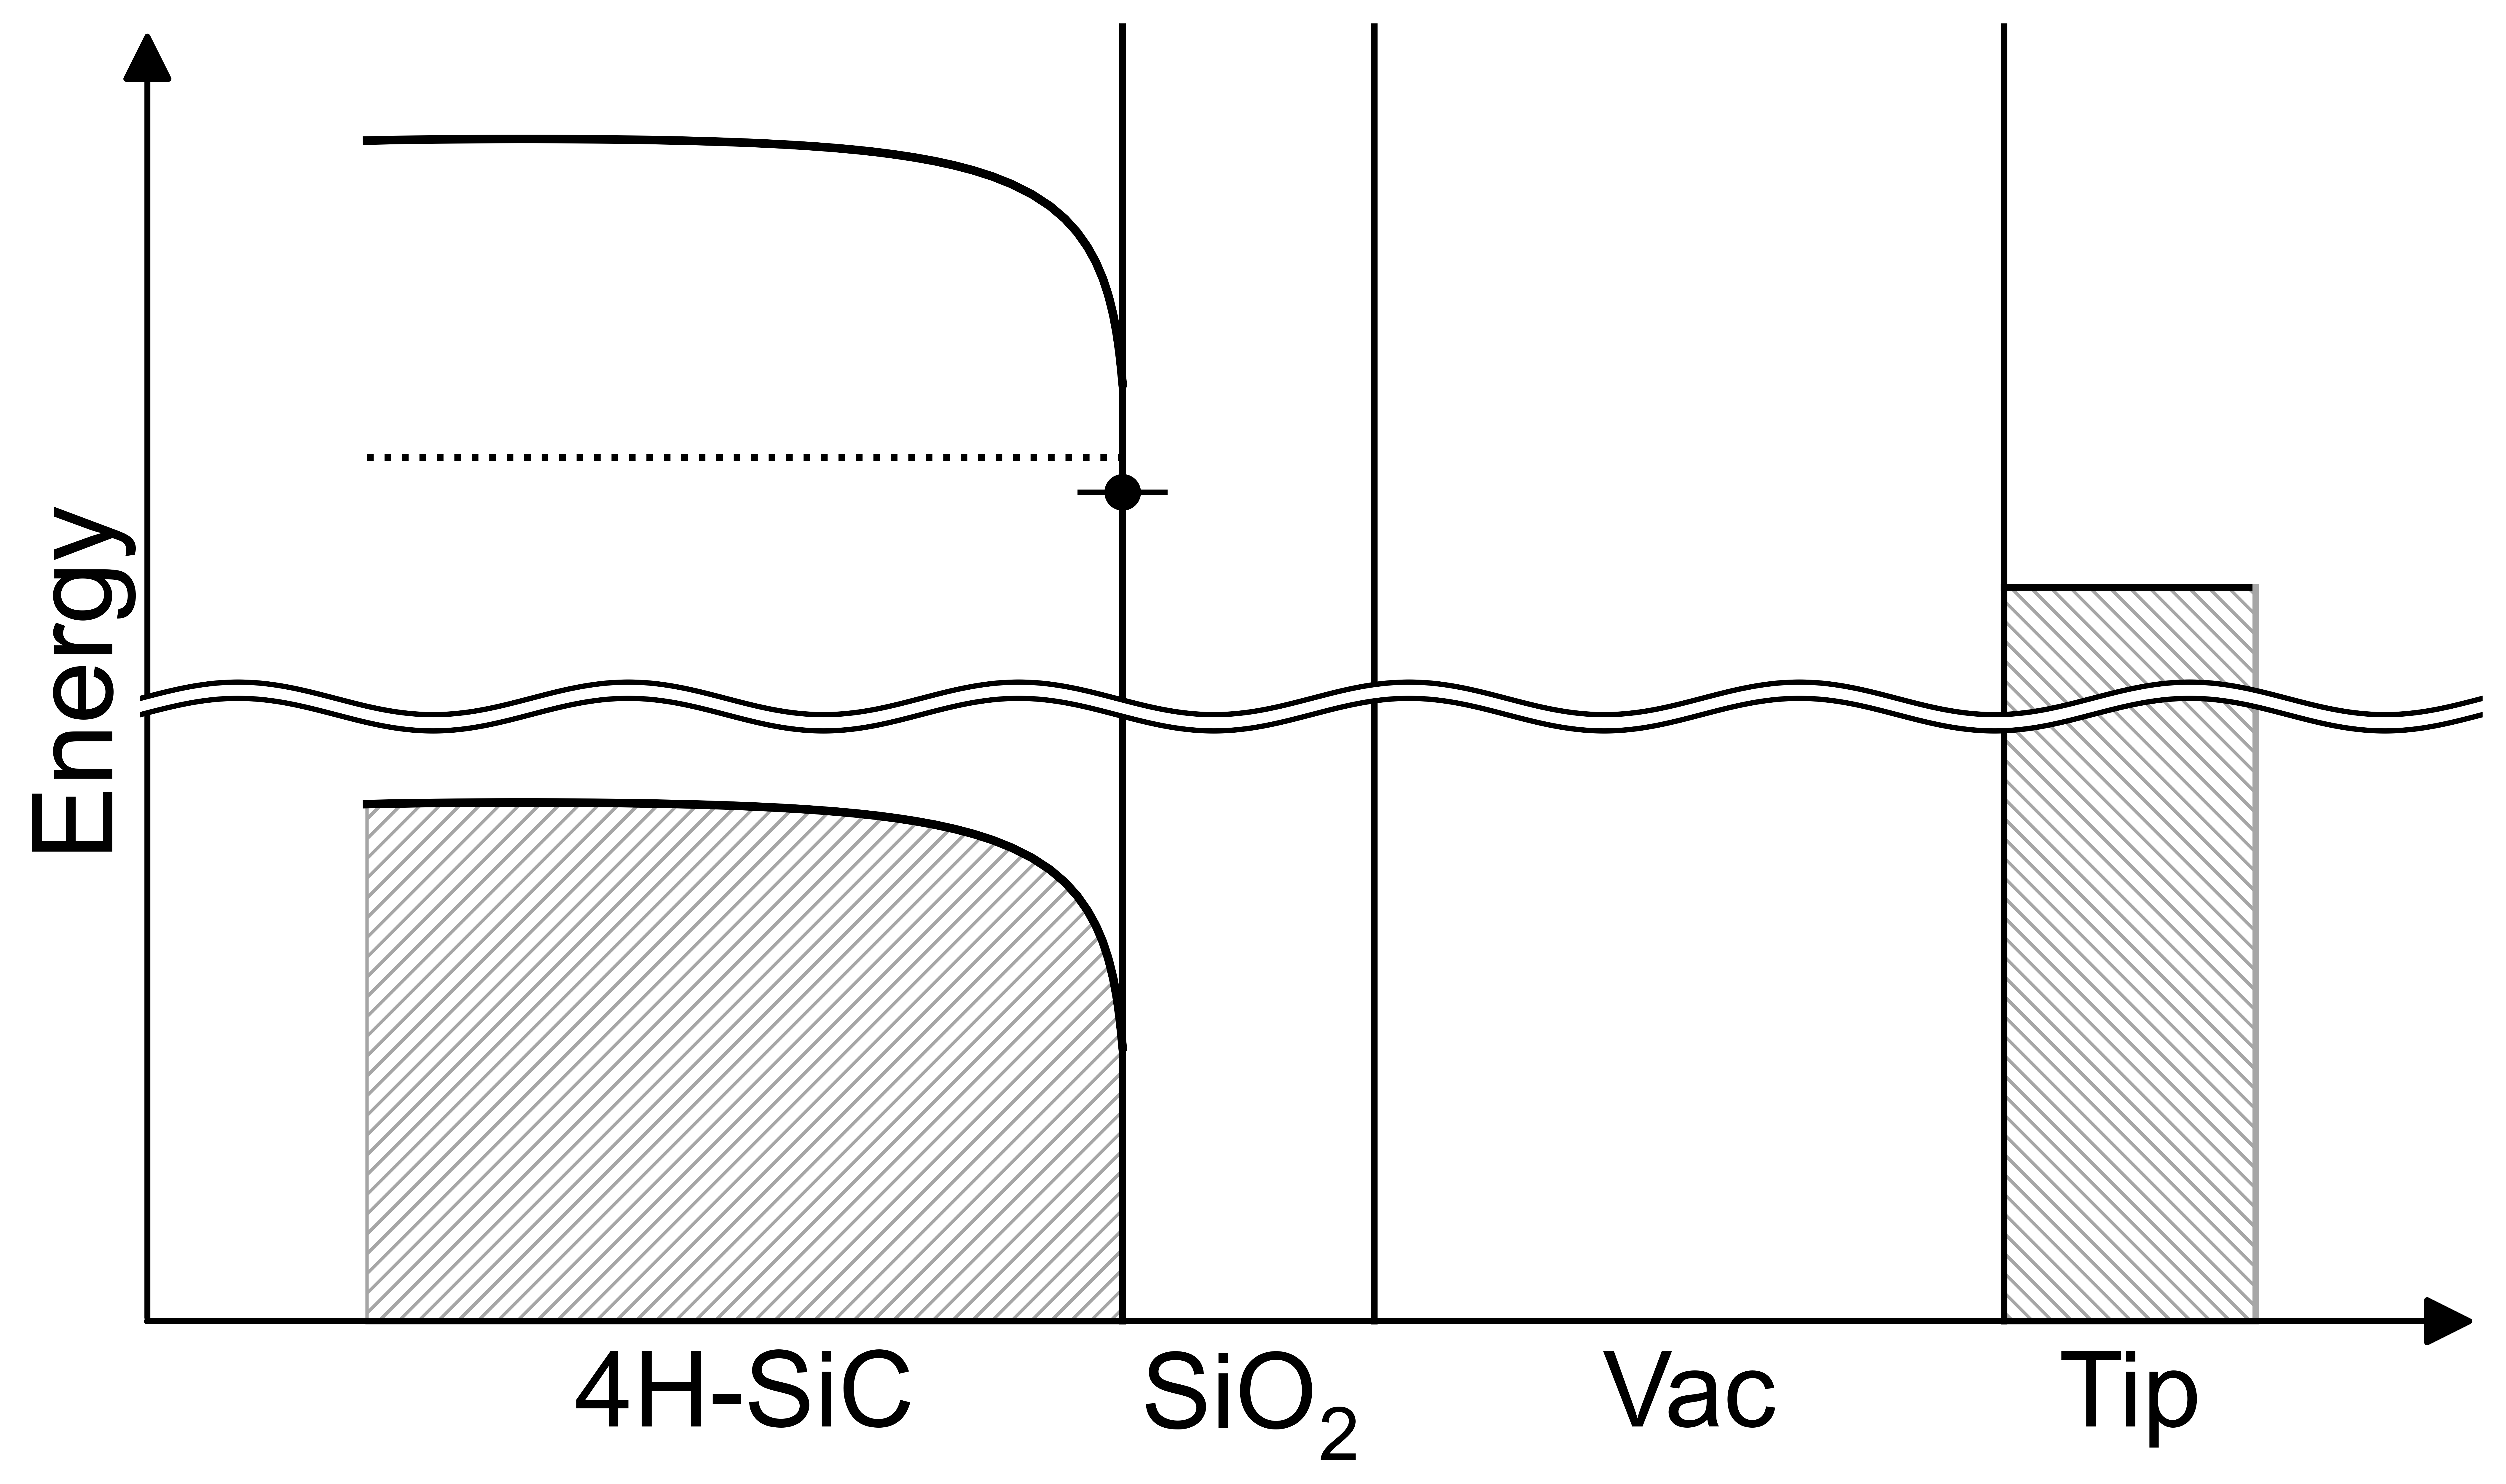

In [7]:
# -*- coding: utf-8 -*-
"""
Band diagram generator
- SiC band bending can be drawn either
  (A) from manual analytical BandBending parameters, or
  (B) from ALLNODES.csv (r≈0, z<0 vertical potential profile).

ALLNODES.csv format expected:
    x (nm), y (nm), u (V)
where
    x = signed radius r [nm]
    y = z [nm]
    u = electrostatic potential [V]

Main update:
- If cfg.band_profile.use_allnodes_profile = True,
  the SiC-side Ec/Ev/Evac are drawn using the potential profile
  extracted from ALLNODES.csv at r≈0 and z<0.
- Other parameters (Ef, Ec bulk position, Ev bulk position, Evac, oxide top, ...)
  remain manually specified as before.
"""

from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams


# ---- Fonts ----
rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "mathtext.sf": "Arial",
    "mathtext.tt": "Arial",
    "mathtext.cal": "Arial",
    "axes.unicode_minus": False,
})

# ======================= 1) Data models =======================

@dataclass
class TrapLevel:
    energy_eV: float
    label: str = ""
    region: str = "interface"   # "sic" | "interface" | "oxide" | "tip"
    x_offset: float = 1.0
    marker_size: int = 90


@dataclass
class BandBending:
    # manual / legacy mode
    delta_Ec_surface_eV: float = 0.0
    delta_Ev_surface_eV: float = 0.0
    curvature: float = 2.0
    use_exponential: bool = False
    lambda_len: float = 0.35


@dataclass
class AllNodesProfileConfig:
    use_allnodes_profile: bool = False
    csv_path: str = "ALLNODES.csv"

    # extract r ~ 0 vertical line
    r_target_nm: float = 0.0
    r_tol_nm: float = 1e-6

    # use only z < 0 (inside sample side)
    z_max_nm: float = -1e-9   # practically z < 0
    z_min_nm: Optional[float] = None

    # mapping from z profile -> drawing x profile
    # z=0 (interface) should correspond to the right edge of SiC (x1)
    # deeper z corresponds to leftward direction
    flip_depth_direction: bool = True

    # potential-to-band conversion:
    # band shift = -(u(z)-u_bulk_ref)
    # for electron energy bands
    # If potential becomes more negative near surface, this gives upward/downward bend accordingly.
    subtract_bulk_reference: bool = True

    # bulk reference position in z-profile:
    # use deepest point if True, else use explicit z
    use_deepest_as_bulk_ref: bool = True
    bulk_ref_z_nm: Optional[float] = None

    # optional smoothing
    smooth_window: int = 1  # odd integer; 1 means no smoothing

    # interpolation points for plotting
    n_interp: int = 500


@dataclass
class RegionWidths:
    sic: float = 4.0
    oxide: float = 0.9
    gap: float = 3.0
    tip: float = 1.0


@dataclass
class LabelOffsets:
    Ec_tag: Tuple[float, float] = (0.06,  0.02)
    Ev_tag: Tuple[float, float] = (0.06, -0.04)
    Ef_tag: Tuple[float, float] = (0.06,  0.02)
    Evac_dy: float = -0.03


@dataclass
class AxesArrowOptions:
    enabled: bool = True
    lw: float = 1.8
    head_width_pts: float = 8.0
    head_length_pts: float = 10.0
    origin_shift_frac: Tuple[float, float] = (0.0, 0.0)
    x_overshoot_frac: float = 0.0
    y_overshoot_frac: float = 0.0


@dataclass
class DiagramConfig:
    # Energies (manual base positions)
    Ev_bulk_eV: float
    Ec_bulk_eV: float
    Ef_sic_eV: float
    Ef_tip_eV: float
    Evac_eV: float

    # Plot range
    y_min_eV: float = 0.0
    y_max_eV: float = 6.0

    # Geometry
    widths: RegionWidths = field(default_factory=RegionWidths)
    show_oxide: bool = True
    sic_oxide_only: bool = False

    # SiO2 upper edge model
    oxide_top_eV: Optional[float] = None
    oxide_follow_scale: float = 1.0
    vacuum_follow_scale: float = 0.0  # unused

    # SiC band bending
    bending: BandBending = field(default_factory=BandBending)

    # NEW: ALLNODES-based band profile
    band_profile: AllNodesProfileConfig = field(default_factory=AllNodesProfileConfig)

    # Traps
    traps: List[TrapLevel] = field(default_factory=list)
    show_traps: bool = True

    # Style
    show_level_tags: bool = True
    label_offsets: LabelOffsets = field(default_factory=LabelOffsets)
    show_hatch_semifilled: bool = True
    figsize: Tuple[float, float] = (12.0, 6.2)
    dpi: int = 160
    fontsize: int = 16

    # Region labels
    region_label_sic: str = "4H-SiC"
    region_label_oxide: str = "SiO$_2$"
    region_label_vac: str = "Vac"
    region_label_tip: str = "Tip"
    region_label_y: float = 0.02
    show_region_labels: bool = True

    # Colors
    colors: Optional[Dict[str, str]] = None

    # Output
    output_path: Optional[object] = None  # None/False→no save, True/"auto"→timestamp, str→path

    # SiC region start
    sic_x_start: float = 0.0
    sic_curve_start_frac: float = 0.0   # used only in manual mode

    # Design tweaks
    ef_sic_extend_left_frac: float = 0.08
    left_blank_frac: float = 0.40

    # Axis arrows
    axes_arrow: AxesArrowOptions = field(default_factory=AxesArrowOptions)

    # Layout lock
    lock_layout: bool = True
    layout_gap_ref: Optional[float] = None
    layout_margin_frac: float = 0.05

    # Vacuum coupling (SiO2 mode)
    eps_oxide_rel: float = 3.9
    vacuum_model: str = "series"    # "series" or "exp"
    vacuum_L0: float = 1.0
    vacuum_coupling_scale: float = 1.0

    # Diamond mode flags
    draw_evac_in_solid: bool = False
    draw_evac_in_tip: bool = False
    show_tip: bool = True

    # Trap marker line
    trap_line_dx_frac: float = 0.012
    trap_line_lw: float = 1.6

    # Energy omission band
    energy_break_enabled: bool = False
    energy_break_range: Optional[Tuple[float, float]] = None
    energy_break_n_periods: float = 6.0
    energy_break_amplitude_frac: float = 0.35

    # 上下の波線の位置を edge からどれだけ内側へ寄せるかを、
    # break band height に対する割合で指定
    # 0.0 なら従来に近い、値を大きくすると2本の波線の間隔が狭くなる
    energy_break_edge_offset_frac: float = 0.25

    # 上下波線それぞれに追加の微調整を入れたい場合
    # 正なら band中心側へ移動、負なら端側へ移動
    energy_break_lower_offset_frac: float = 0.0
    energy_break_upper_offset_frac: float = 0.0
    
# ======================= 2) Utilities =======================

def _C(cfg: DiagramConfig, key: str, default_gray: str) -> str:
    return (cfg.colors or {}).get(key, default_gray)


def _shape_value(t: np.ndarray, curv: float, use_exp: bool, L: float) -> np.ndarray:
    t = np.clip(t, 0.0, 1.0)
    if use_exp:
        L = max(1e-9, L)
        s = 1.0 - np.exp(-t / L)
        s /= (1.0 - np.exp(-1.0 / L))
        return s
    return t ** max(1.0, curv)


def _auto_filename(prefix: str = "band_diagram", ext: str = "svg") -> str:
    return f"{prefix}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.{ext}"


def _draw_axis_arrows(ax, xmin, xmax, ymin, ymax, opts: AxesArrowOptions):
    xr = (xmax - xmin)
    yr = (ymax - ymin)
    ox = xmin + opts.origin_shift_frac[0] * xr
    oy = ymin + opts.origin_shift_frac[1] * yr
    x_start = xmin - opts.x_overshoot_frac * xr
    x_end   = xmax + opts.x_overshoot_frac * xr
    y_start = ymin - opts.y_overshoot_frac * yr
    y_end   = ymax + opts.y_overshoot_frac * yr

    ax.annotate(
        "", xy=(x_end, oy), xytext=(x_start, oy),
        arrowprops=dict(arrowstyle="-|>", lw=opts.lw, color="0.0"),
        clip_on=False
    )
    ax.annotate(
        "", xy=(ox, y_end), xytext=(ox, y_start),
        arrowprops=dict(arrowstyle="-|>", lw=opts.lw, color="0.0"),
        clip_on=False
    )


def _eta_gap(cfg: DiagramConfig, w: RegionWidths) -> float:
    """η(s): 0→weak coupling (far), 1→strong (near)."""
    s = max(0.0, float(w.gap))
    if s <= 1e-12:
        return 1.0
    if cfg.vacuum_model.lower() == "exp":
        L0 = max(1e-9, float(cfg.vacuum_L0))
        eta = np.exp(-s / L0)
    else:
        t_ox = max(1e-9, float(w.oxide if w.oxide > 0.0 else 1.0))
        eta = 1.0 / (1.0 + cfg.eps_oxide_rel * s / t_ox)
    return float(np.clip(eta, 0.0, 1.0))


def _draw_energy_break_band(ax, cfg: DiagramConfig, xmin: float, xmax: float):
    if (not cfg.energy_break_enabled) or (cfg.energy_break_range is None):
        return

    E_low, E_high = cfg.energy_break_range
    y0 = max(min(E_low, E_high), cfg.y_min_eV)
    y1 = min(max(E_low, E_high), cfg.y_max_eV)
    if y1 <= y0 + 1e-6:
        return

    xs = np.linspace(xmin, xmax, 800)
    band_height = y1 - y0
    y_mid = 0.5 * (y0 + y1)

    # ---- NEW: edge からのオフセットで上下波線位置を決める ----
    base_off = cfg.energy_break_edge_offset_frac * band_height
    low_extra = cfg.energy_break_lower_offset_frac * band_height
    up_extra  = cfg.energy_break_upper_offset_frac * band_height

    # 下側波線の中心位置
    y_mid_low = y0 + base_off + low_extra
    # 上側波線の中心位置
    y_mid_up  = y1 - base_off - up_extra

    # 2本が交差しないように保護
    min_sep = 0.05 * band_height
    if y_mid_up <= y_mid_low + min_sep:
        y_mid_low = y_mid - 0.5 * min_sep
        y_mid_up  = y_mid + 0.5 * min_sep

    A = 0.5 * cfg.energy_break_amplitude_frac * band_height

    n_periods = max(1.0, float(cfg.energy_break_n_periods))
    phase = 2.0 * np.pi * n_periods * (xs - xmin) / max(1e-12, (xmax - xmin))

    y_wave_low = y_mid_low + A * np.sin(phase)
    y_wave_up  = y_mid_up  + A * np.sin(phase)

    ax.fill_between(xs, y_wave_low, y_wave_up, color="white", zorder=8)
    ax.plot(xs, y_wave_low, color="black", linewidth=1.6, zorder=9)
    ax.plot(xs, y_wave_up,  color="black", linewidth=1.6, zorder=9)



# ======================= 3) ALLNODES reader =======================

def _normalize_allnodes_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = {c.strip(): c for c in df.columns}

    x_col = None
    y_col = None
    u_col = None

    for c in df.columns:
        cs = c.strip().lower()
        if cs in ("x (nm)", "x[nm]", "x_nm", "x"):
            x_col = c
        elif cs in ("y (nm)", "y[nm]", "y_nm", "y", "z (nm)", "z[nm]", "z_nm", "z"):
            y_col = c
        elif cs in ("u (v)", "u[v]", "u_v", "u", "potential (v)", "potential"):
            u_col = c

    if x_col is None or y_col is None or u_col is None:
        raise ValueError(
            "ALLNODES.csv columns could not be identified. "
            "Expected something like: 'x (nm)', 'y (nm)', 'u (V)'."
        )

    out = pd.DataFrame({
        "x_nm": pd.to_numeric(df[x_col], errors="coerce"),
        "z_nm": pd.to_numeric(df[y_col], errors="coerce"),
        "u_V":  pd.to_numeric(df[u_col], errors="coerce"),
    }).dropna()

    return out


def _smooth_1d(y: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return y.copy()
    if window % 2 == 0:
        window += 1
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(ypad, kernel, mode="valid")


def load_allnodes_vertical_profile(cfg: DiagramConfig) -> pd.DataFrame:
    ap = cfg.band_profile
    path = Path(ap.csv_path)
    if not path.exists():
        raise FileNotFoundError(f"ALLNODES.csv not found: {path}")

    df = pd.read_csv(path)
    df = _normalize_allnodes_columns(df)

    # r≈0
    df = df[np.abs(df["x_nm"] - ap.r_target_nm) <= ap.r_tol_nm].copy()

    # z<0
    df = df[df["z_nm"] < ap.z_max_nm].copy()

    if ap.z_min_nm is not None:
        df = df[df["z_nm"] >= ap.z_min_nm].copy()

    if df.empty:
        raise ValueError(
            "No valid points found for the requested r≈0 and z<0 filter. "
            "Increase r_tol_nm or check the ALLNODES.csv content."
        )

    # average duplicate z points if any
    prof = (
        df.groupby("z_nm", as_index=False)["u_V"]
        .mean()
        .sort_values("z_nm")
        .reset_index(drop=True)
    )

    if ap.smooth_window > 1:
        prof["u_V"] = _smooth_1d(prof["u_V"].to_numpy(), ap.smooth_window)

    return prof


def build_sic_bands_from_allnodes(cfg: DiagramConfig, xs: np.ndarray, x0: float, x1: float):
    """
    Build Ec/Ev directly from ALLNODES vertical potential profile.

    Mapping:
    - interface (z≈0-)   -> x=x1
    - deeper bulk (more negative z) -> x toward x0

    Band shift:
        dE(x) = -(u(x) - u_bulk_ref)
    and
        Ec(x) = Ec_bulk + dE(x)
        Ev(x) = Ev_bulk + dE(x)
    """
    ap = cfg.band_profile
    prof = load_allnodes_vertical_profile(cfg)

    z = prof["z_nm"].to_numpy(dtype=float)
    u = prof["u_V"].to_numpy(dtype=float)

    # choose bulk reference potential
    if ap.subtract_bulk_reference:
        if ap.use_deepest_as_bulk_ref or ap.bulk_ref_z_nm is None:
            u_bulk = float(u[0])  # deepest point because z sorted ascending: most negative first
        else:
            u_bulk = float(np.interp(ap.bulk_ref_z_nm, z, u))
    else:
        u_bulk = 0.0

    # convert z -> normalized depth coordinate
    z_interface = float(np.max(z))  # closest to 0, still below interface
    z_deep = float(np.min(z))       # deepest inside bulk

    if np.isclose(z_interface, z_deep):
        raise ValueError("The z-range in ALLNODES profile is too small.")

    # define depth d: 0 at interface, positive toward bulk
    d = z_interface - z
    d_max = float(np.max(d))
    if d_max <= 0:
        raise ValueError("Invalid depth range extracted from ALLNODES profile.")

    # map depth onto x coordinate in SiC region
    # interface -> x1, deep bulk -> x0
    x_prof = x1 - (d / d_max) * (x1 - x0)

    # sort by x increasing for interpolation
    order = np.argsort(x_prof)
    x_prof = x_prof[order]
    u_prof = u[order]

    # interpolate u(x) onto requested xs
    u_x = np.interp(xs, x_prof, u_prof)

    dE = -(u_x - u_bulk)
    Ec = cfg.Ec_bulk_eV + dE
    Ev = cfg.Ev_bulk_eV + dE
    return Ec, Ev


# ======================= 4) Legacy/manual SiC bands =======================

def _sic_bands_manual(cfg: DiagramConfig, xs: np.ndarray, L: float):
    x_local = xs - xs[0]
    start_local = np.clip(cfg.sic_curve_start_frac, 0.0, 1.0) * L
    if L <= 1e-12 or start_local >= L:
        s = np.zeros_like(xs)
    else:
        u = (x_local - start_local) / max(1e-12, (L - start_local))
        u = np.clip(u, 0.0, 1.0)
        s = _shape_value(
            u,
            cfg.bending.curvature,
            cfg.bending.use_exponential,
            cfg.bending.lambda_len
        )
        s[x_local < start_local] = 0.0
    Ec = cfg.Ec_bulk_eV + cfg.bending.delta_Ec_surface_eV * s
    Ev = cfg.Ev_bulk_eV + cfg.bending.delta_Ev_surface_eV * s
    return Ec, Ev


def _sic_bands(cfg: DiagramConfig, xs: np.ndarray, x0: float, x1: float):
    if cfg.band_profile.use_allnodes_profile:
        return build_sic_bands_from_allnodes(cfg, xs, x0, x1)
    return _sic_bands_manual(cfg, xs, x1 - x0)


def _sic_shift_at_x(x: float, x0: float, x1: float, cfg: DiagramConfig) -> float:
    xs = np.array([x0, x], dtype=float)
    Ec, _ = _sic_bands(cfg, xs, x0, x1)
    return float(Ec[-1] - cfg.Ec_bulk_eV)


def _oxide_Ec(cfg: DiagramConfig, x_local: np.ndarray, Lox: float, delta_Ec_surface_abs: float):
    """Ec in oxide (guide), not allowed to reach vacuum."""
    base = cfg.oxide_top_eV
    if base is None:
        base = min(cfg.Evac_eV - 0.3, cfg.y_max_eV * 0.90)
    if Lox <= 1e-12:
        return np.full_like(x_local, fill_value=base)
    s_lin = np.clip(x_local / Lox, 0.0, 1.0)
    Ec_ox = base + cfg.oxide_follow_scale * delta_Ec_surface_abs * s_lin
    return np.minimum(Ec_ox, cfg.Evac_eV - 1e-6)


# ======================= 5) Main draw =======================

def draw_band_diagram(cfg: DiagramConfig):
    plt.rcParams.update({
        "font.size": cfg.fontsize,
        "axes.titlesize": cfg.fontsize + 2,
        "axes.labelsize": cfg.fontsize + 2,
        "xtick.labelsize": cfg.fontsize,
        "ytick.labelsize": cfg.fontsize,
    })

    # --- positions from widths ---
    w = cfg.widths
    x0 = cfg.sic_x_start
    x1 = x0 + w.sic
    x2 = x1 + (w.oxide if cfg.show_oxide else 0.0)
    x3 = x2 + w.gap
    x4 = x3 + w.tip

    show_tip = cfg.show_tip and (not cfg.sic_oxide_only)

    if cfg.sic_oxide_only:
        layout_total_w = w.sic + (w.oxide if cfg.show_oxide else 0.0)
        x_right_layout = x2
    else:
        layout_gap = (
            cfg.layout_gap_ref
            if (cfg.lock_layout and cfg.layout_gap_ref is not None)
            else w.gap
        )
        layout_total_w = w.sic + (w.oxide if cfg.show_oxide else 0.0) + layout_gap + w.tip
        x_right_layout = x0 + layout_total_w

    fig, ax = plt.subplots(figsize=cfg.figsize, dpi=cfg.dpi)
    fig.subplots_adjust(bottom=0.22)

    # --- SiC bands ---
    xs_sic = np.linspace(x0, x1, cfg.band_profile.n_interp)
    Ec_sic, Ev_sic = _sic_bands(cfg, xs_sic, x0, x1)

    # surface shift for oxide/vacuum continuation
    delta_Ec_surface_now = float(Ec_sic[-1] - cfg.Ec_bulk_eV)

    # Vacuum level in SiC
    Evac_sic = cfg.Evac_eV + (Ec_sic - cfg.Ec_bulk_eV)
    Evac_surf = float(Evac_sic[-1])

    # Fermi (SiC)
    ef_dx = cfg.ef_sic_extend_left_frac * (x1 - x0)
    x_ef_left = x0 - ef_dx

    ax.plot(xs_sic, Ec_sic, linewidth=2.6, color=_C(cfg, "Ec_sic", "0.00"))
    ax.plot(xs_sic, Ev_sic, linewidth=2.6, color=_C(cfg, "Ev_sic", "0.00"))
    ax.plot(
        [x_ef_left, x1], [cfg.Ef_sic_eV, cfg.Ef_sic_eV],
        linestyle=":", linewidth=2.0, color=_C(cfg, "Ef_sic", "0.00")
    )

    if cfg.show_level_tags:
        dx, dy = cfg.label_offsets.Ec_tag
        ax.text(x0 + dx*(x1-x0), Ec_sic[0] + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{C}$")
        dx, dy = cfg.label_offsets.Ev_tag
        ax.text(x0 + dx*(x1-x0), Ev_sic[0] + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{V}$")
        dx, dy = cfg.label_offsets.Ef_tag
        ax.text(x0 + dx*(x1-x0), cfg.Ef_sic_eV + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{F}$")

    if cfg.show_hatch_semifilled:
        ax.fill_between(
            xs_sic, cfg.y_min_eV, Ev_sic,
            hatch="////", facecolor="none",
            edgecolor=_C(cfg, "hatch", "0.65"), zorder=1
        )

    # --- Oxide ---
    if cfg.show_oxide and w.oxide > 0:
        xs_ox = np.linspace(x1, x2, 300)
        Ec_ox = _oxide_Ec(cfg, xs_ox - x1, w.oxide, abs(delta_Ec_surface_now))
        ax.plot(xs_ox, Ec_ox, linewidth=2.4, color=_C(cfg, "Ec_oxide", "0.0"))

        ox_top_base = cfg.oxide_top_eV
        if ox_top_base is None:
            ox_top_base = min(cfg.Evac_eV - 0.3, cfg.y_max_eV * 0.90)

        vac_left = Evac_surf
        vac_right = Evac_surf + cfg.oxide_follow_scale * abs(delta_Ec_surface_now)

        left_band_top = float(Ec_ox[0])
        right_band_top = float(Ec_ox[-1])

        ox_top_left = min(left_band_top, vac_left, ox_top_base)
        ox_top_right = min(right_band_top, vac_right, ox_top_base)

        ax.plot([x1, x1], [cfg.y_min_eV, ox_top_left], linewidth=2.0, color=_C(cfg, "oxide_border", "0.0"))
        if not cfg.sic_oxide_only:
            ax.plot([x2, x2], [cfg.y_min_eV, ox_top_right], linewidth=2.0, color=_C(cfg, "oxide_border", "0.0"))

    # --- Tip metal ---
    if show_tip:
        ax.plot([x3, x4], [cfg.Ef_tip_eV, cfg.Ef_tip_eV], linewidth=2.0, color=_C(cfg, "Ef_tip", "0.0"))
        if cfg.show_hatch_semifilled:
            ax.fill_between(
                [x3, x4], cfg.y_min_eV, [cfg.Ef_tip_eV, cfg.Ef_tip_eV],
                step="pre", hatch="\\\\\\\\", facecolor="none",
                edgecolor=_C(cfg, "hatch", "0.65")
            )

    # --- Vacuum level Evac(x) ---
    if cfg.show_oxide:
        ax.plot(xs_sic, Evac_sic, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

        if w.oxide > 0:
            xs_ox = np.linspace(x1, x2, 300)
            s_lin_ox = (xs_ox - x1) / max(1e-12, (x2 - x1))
            Evac_ox = Evac_surf + cfg.oxide_follow_scale * abs(delta_Ec_surface_now) * s_lin_ox
            ax.plot(xs_ox, Evac_ox, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))
            Evac_right = float(Evac_ox[-1])
        else:
            Evac_right = Evac_surf

        if not cfg.sic_oxide_only:
            bend_sign = 1.0 if delta_Ec_surface_now >= 0.0 else -1.0
            eta = _eta_gap(cfg, w)
            delta_tip = bend_sign * cfg.vacuum_coupling_scale * abs(delta_Ec_surface_now) * eta
            Evac_at_x3 = float(Evac_right + delta_tip)

            if w.gap > 1e-12:
                xs_gap = np.linspace(x2, x3, 200)
                s_lin_gap = (xs_gap - x2) / max(1e-12, (x3 - x2))
                Evac_gap = (1.0 - s_lin_gap) * Evac_right + s_lin_gap * Evac_at_x3
                ax.plot(xs_gap, Evac_gap, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

            if show_tip:
                ax.plot([x3, x3], [cfg.y_min_eV, Evac_at_x3], linewidth=2.0, color=_C(cfg, "tip_border", "0.0"))
                ax.plot([x4, x4], [cfg.y_min_eV, cfg.Ef_tip_eV], linewidth=2.0, color=_C(cfg, "tip_border", "0.65"))
                ax.plot([x3, x4], [Evac_at_x3, Evac_at_x3], linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

    else:
        if cfg.draw_evac_in_solid:
            ax.plot(xs_sic, Evac_sic, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

        ax.plot([x1, x1], [cfg.y_min_eV, cfg.y_max_eV], linewidth=2.0, color=_C(cfg, "vac_border", "0.0"))

        Evac_right = Evac_surf
        if w.gap > 1e-12:
            ax.plot([x1, x3], [Evac_right, Evac_right], linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

        if show_tip:
            ax.plot([x3, x3], [cfg.y_min_eV, cfg.y_max_eV], linewidth=2.0, color=_C(cfg, "tip_border", "0.0"))
            ax.plot([x4, x4], [cfg.y_min_eV, cfg.Ef_tip_eV], linewidth=2.0, color=_C(cfg, "tip_border", "0.65"))

    # --- Region labels ---
    if cfg.show_region_labels:
        y_axes = -cfg.region_label_y
        trans = ax.get_xaxis_transform()
        ax.text((x0+x1)/2, y_axes, cfg.region_label_sic, transform=trans, ha="center", va="top")
        if cfg.show_oxide and w.oxide > 0:
            ax.text((x1+x2)/2, y_axes, cfg.region_label_oxide, transform=trans, ha="center", va="top")
            if not cfg.sic_oxide_only:
                ax.text((x2+x3)/2, y_axes, cfg.region_label_vac, transform=trans, ha="center", va="top")
        else:
            if not cfg.sic_oxide_only:
                ax.text((x1+x3)/2, y_axes, cfg.region_label_vac, transform=trans, ha="center", va="top")
        if show_tip:
            ax.text((x3+x4)/2, y_axes, cfg.region_label_tip, transform=trans, ha="center", va="top")

    # --- Traps ---
    if cfg.show_traps and cfg.traps:
        if cfg.sic_oxide_only:
            layout_total_w_for_trap = w.sic + (w.oxide if cfg.show_oxide else 0.0)
        else:
            layout_total_w_for_trap = (
                w.sic + (w.oxide if cfg.show_oxide else 0.0) +
                (cfg.layout_gap_ref if (cfg.lock_layout and cfg.layout_gap_ref is not None) else w.gap) +
                w.tip
            )
        half_dx = 0.5 * cfg.trap_line_dx_frac * layout_total_w_for_trap

        for tr in cfg.traps:
            if tr.region in ("sic", "interface"):
                x_tr = x0 + np.clip(tr.x_offset, 0.0, 1.0) * (x1 - x0)
                dE = _sic_shift_at_x(x_tr, x0, x1, cfg)
                Ef_ref = cfg.Ef_sic_eV
            elif tr.region == "oxide" and cfg.show_oxide and w.oxide > 0:
                x_tr = x1 + np.clip(tr.x_offset, 0.0, 1.0) * (x2 - x1)
                s_lin = float(np.clip((x_tr - x1) / max(1e-12, (x2 - x1)), 0.0, 1.0))
                dE = cfg.oxide_follow_scale * abs(delta_Ec_surface_now) * s_lin
                Ef_ref = cfg.Ef_sic_eV
            elif tr.region == "tip" and show_tip:
                x_tr = x3 + np.clip(tr.x_offset, 0.0, 1.0) * (x4 - x3)
                dE = 0.0
                Ef_ref = cfg.Ef_tip_eV
            else:
                continue

            y_tr = tr.energy_eV + dE
            above = (y_tr > Ef_ref)
            face = "white" if above else "black"
            edge = "black"

            ax.scatter([x_tr], [y_tr], s=tr.marker_size, marker="o",
                       facecolors=face, edgecolors=edge, linewidths=1.6,
                       zorder=10, clip_on=False)
            ax.plot([x_tr - half_dx, x_tr + half_dx], [y_tr, y_tr],
                    color="black", linewidth=cfg.trap_line_lw,
                    zorder=11, clip_on=False)

            if tr.label:
                ax.text(x_tr + 0.02*layout_total_w_for_trap, y_tr, tr.label,
                        va="center", zorder=12)

    # --- Cosmetics ---
    left_blank = cfg.left_blank_frac * (x1 - x0)
    xmin_candidates = [
        x0 - left_blank,
        x_ef_left - 0.02*(x_right_layout - x0),
        x0 - cfg.layout_margin_frac*(x_right_layout - x0)
    ]
    xmin = min(xmin_candidates)
    xmax = x_right_layout + cfg.layout_margin_frac*(x_right_layout - x0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(cfg.y_min_eV, cfg.y_max_eV)
    ax.set_xlabel("")
    ax.set_ylabel("Energy")

    for s in ["top", "right", "bottom", "left"]:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    ax.tick_params(axis="y", which="both", left=False, labelleft=False)

    _draw_energy_break_band(ax, cfg, xmin, xmax)

    if cfg.axes_arrow.enabled:
        _draw_axis_arrows(ax, xmin, xmax, cfg.y_min_eV, cfg.y_max_eV, cfg.axes_arrow)

    fig.tight_layout()

    out = cfg.output_path
    if out is True or (isinstance(out, str) and str(out).lower() == "auto"):
        out = _auto_filename(prefix="band_diagram", ext="svg")
    elif out in (None, False):
        out = None

    if isinstance(out, str) and out.strip():
        fig.savefig(out, bbox_inches="tight")
        print(f"[saved] {out}")

    return fig, ax


# ======================= 6) Example =======================

if __name__ == "__main__":
    # ---- manual parameters kept as before ----
    Ef_sic_val = 6.1165 -0.05
    phi_SiC = 3.77
    Evac_val = Ef_sic_val + phi_SiC
    phi_tip = 0.1
    Ef_tip_val = Ef_sic_val - phi_tip
    oxide_top_val = Evac_val - 0.2

    cfg = DiagramConfig(
        Ev_bulk_eV=5.8,
        Ec_bulk_eV=6.31,
        Ef_sic_eV=Ef_sic_val,
        Ef_tip_eV=Ef_tip_val,
        Evac_eV=Evac_val,

        y_min_eV=5.4,
        y_max_eV=6.4,

        widths=RegionWidths(sic=3.0, oxide=1.0, gap=1, tip=1.0),
        show_oxide=True,
        sic_oxide_only=False,

        oxide_top_eV=oxide_top_val,
        oxide_follow_scale=-3.3,

        # legacy/manual values remain here, but ignored if use_allnodes_profile=True
        bending=BandBending(
            delta_Ec_surface_eV=-0.157,
            delta_Ev_surface_eV=-0.157,
            curvature=2.0,
            use_exponential=False,
            lambda_len=0.35
        ),

        # ---- NEW ----
        band_profile=AllNodesProfileConfig(
            use_allnodes_profile=True,
            csv_path="20260312_143248_ALLNODES.csv",
            r_target_nm=0.0,
            r_tol_nm=1e-6,      # 必要なら 0.05 や 0.1 などに広げる
            z_max_nm=-5,     # z < 0
            z_min_nm=None,      # 必要なら -50 など
            subtract_bulk_reference=True,
            use_deepest_as_bulk_ref=True,
            bulk_ref_z_nm=None,
            smooth_window=1,    # 必要なら 3,5,...
            n_interp=500,
        ),

        traps=[
#             TrapLevel(energy_eV=Ef_sic_val-0.62+0.153
# , label=r"", region="interface"),
#               TrapLevel(energy_eV=Ef_sic_val-0.06+0.153
# , label=r"", region="interface"),
#               TrapLevel(energy_eV=Ef_sic_val+0.03+0.153
# , label=r"", region="interface"),
              TrapLevel(energy_eV=Ef_sic_val+0.14 +0.02
, label=r"", region="interface")
              ],
        show_traps=True,

        show_level_tags=False,
        figsize=(11.326, 7),
        dpi=800,
        fontsize=32,

        ef_sic_extend_left_frac=0.0,
        left_blank_frac=0.30,

        axes_arrow=AxesArrowOptions(
            enabled=True, lw=1.8,
            origin_shift_frac=(0.003, 0.0025),
            x_overshoot_frac=0.00,
            y_overshoot_frac=0.00
        ),

        lock_layout=True,
        layout_gap_ref=3.0,
        layout_margin_frac=0.05,

        eps_oxide_rel=3.9,
        vacuum_model="series",
        vacuum_L0=1.2,
        vacuum_coupling_scale=1.0,

        show_region_labels=True,
        show_tip=True,

        trap_line_dx_frac=0.042,
        trap_line_lw=1.6,

        energy_break_enabled=True,
        energy_break_range=(5.75, 6.0),
        energy_break_n_periods=6.0,
        energy_break_amplitude_frac=0.1,
        energy_break_edge_offset_frac=0.5,
        energy_break_lower_offset_frac=0.00,
        energy_break_upper_offset_frac=0.00,

        output_path=True,
        sic_x_start=2.5,
        sic_curve_start_frac=0.60,  # manual mode only
        
    )
    cfg.widths.gap =2.5
    draw_band_diagram(cfg)
    plt.show()

[saved] band_diagram_20251208_152258.png


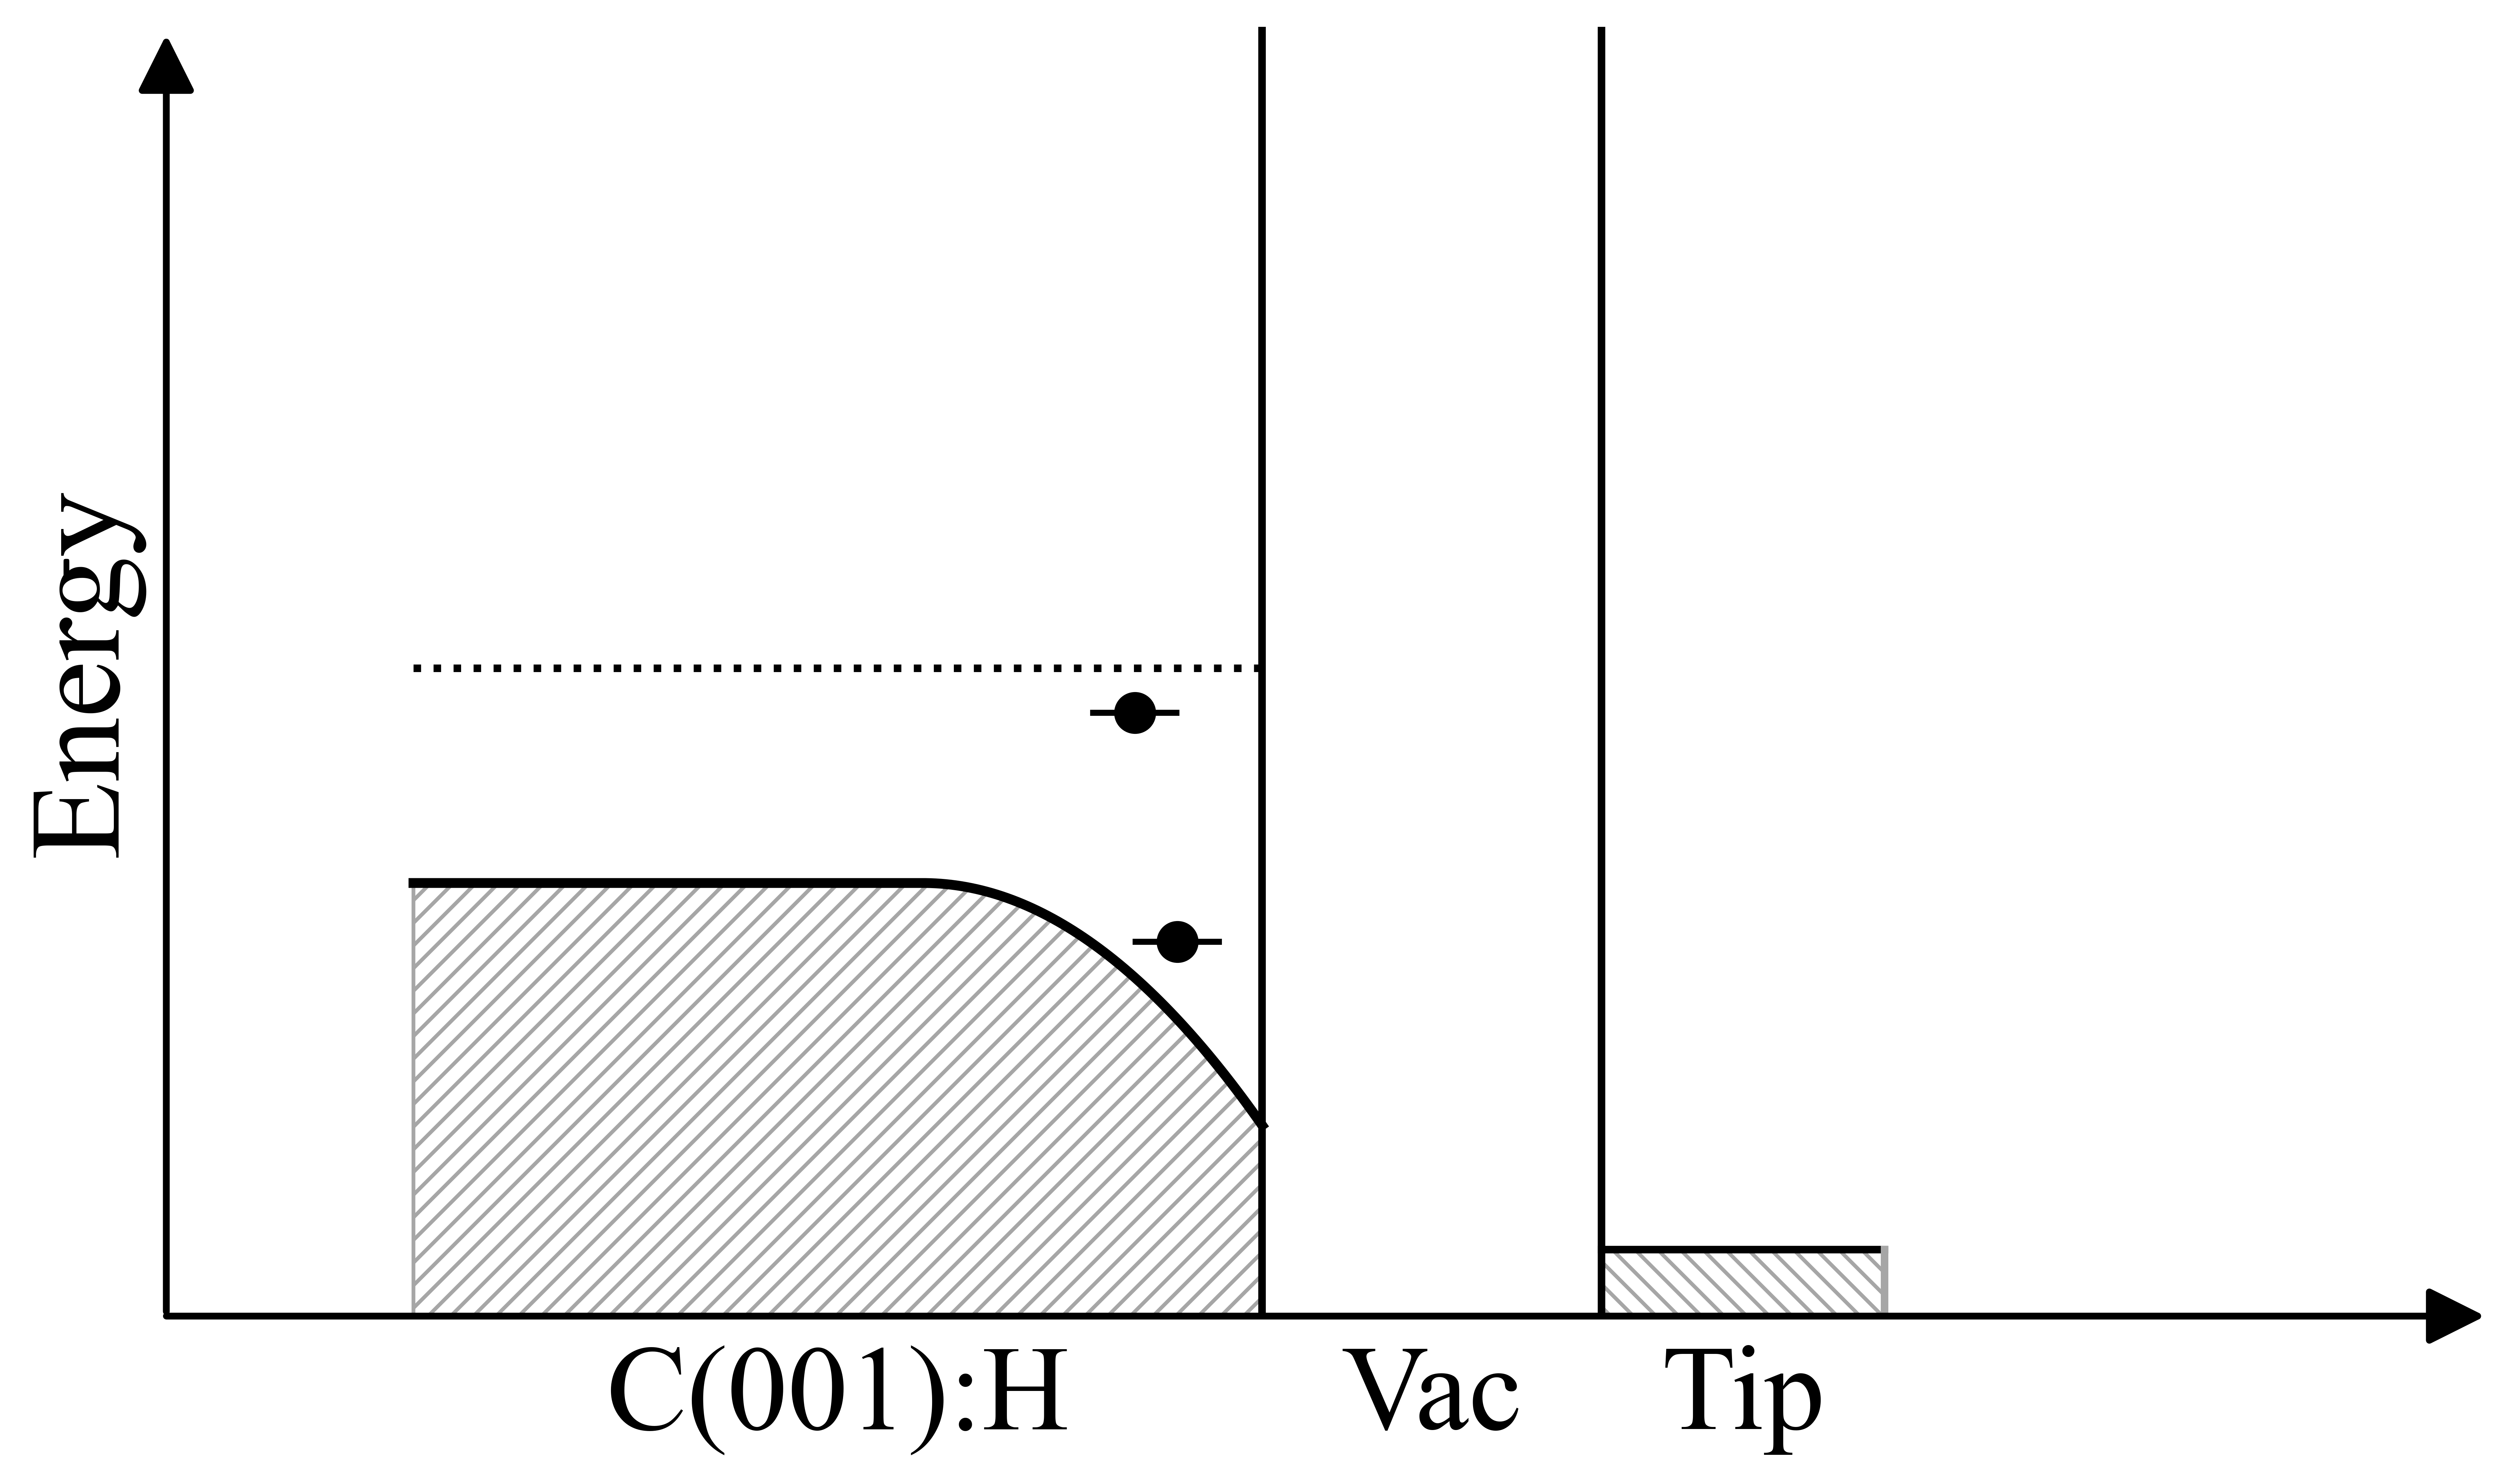

In [191]:
# -*- coding: utf-8 -*-
"""
Band diagram generator (diamond, no-oxide default) with layout lock
- C(001)/vac のとき：固体内部では E_vac を描かない（既定）
- AFM tip 内でも E_vac を描かない（既定）
- 真空中の E_vac は C(001)/vac 界面の値を水平に維持（tip 内へは延長しない）
- 酸化膜なしのときは C(001)/vac 界面の縦線を明示表示
- レイアウト固定（gap を変えても基板側は据え置き、tip のみ水平移動）

更新点:
- トラップ記号を「円＋中心を貫く短い水平線」に変更
- y_tr > E_F → face='white', edge='black'（白丸黒枠＋黒線）
  y_tr <= E_F → face='black', edge='black'（黒丸＋黒線）
- TrapLevel.x_offset で左右位置調整、該当位置のバンドベンド量で縦位置を補正
- ★ Region ラベルを一括トグルする `show_region_labels` を追加
"""

from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib import rcParams

# ---- Fonts ----
rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
    "mathtext.sf": "Times New Roman",
    "mathtext.tt": "Times New Roman",
    "mathtext.cal": "Times New Roman",
    "axes.unicode_minus": False,
})

# ======================= 1) Data models =======================

@dataclass
class TrapLevel:
    energy_eV: float
    label: str = ""
    region: str = "interface"   # "sic" | "interface" | "tip"
    x_offset: float = 1.0       # SiC幅に対する相対位置（0=左端, 1=界面）
    marker_size: int = 90

@dataclass
class BandBending:
    delta_Ec_surface_eV: float = 0.0
    delta_Ev_surface_eV: float = 0.0
    curvature: float = 2.0
    use_exponential: bool = False
    lambda_len: float = 0.35

@dataclass
class RegionWidths:
    sic: float = 4.0
    oxide: float = 0.0
    gap: float = 2.0
    tip: float = 1.35

@dataclass
class LabelOffsets:
    Ec_tag: Tuple[float, float] = (0.06,  0.02)
    Ev_tag: Tuple[float, float] = (0.06, -0.04)
    Ef_tag: Tuple[float, float] = (0.06,  0.02)
    Evac_dy: float = -0.03

@dataclass
class AxesArrowOptions:
    enabled: bool = True
    lw: float = 1.8
    head_width_pts: float = 8.0
    head_length_pts: float = 10.0
    origin_shift_frac: Tuple[float, float] = (0.0, 0.0)
    x_overshoot_frac: float = 0.0
    y_overshoot_frac: float = 0.0

@dataclass
class DiagramConfig:
    # Energies (eV)
    Ev_bulk_eV: float
    Ec_bulk_eV: float
    Ef_sic_eV: float
    Ef_tip_eV: float
    Evac_eV: float

    # Plot range
    y_min_eV: float = 0.0
    y_max_eV: float = 6.0

    # Geometry
    widths: RegionWidths = field(default_factory=RegionWidths)
    show_oxide: bool = False

    # 互換（未使用）
    oxide_top_eV: Optional[float] = None
    oxide_follow_scale: float = 1.0
    vacuum_follow_scale: float = 0.0

    # C(001) band bending
    bending: BandBending = field(default_factory=BandBending)

    # Traps
    traps: List[TrapLevel] = field(default_factory=list)
    show_traps: bool = True

    # Style
    show_level_tags: bool = True
    label_offsets: LabelOffsets = field(default_factory=LabelOffsets)
    show_hatch_semifilled: bool = True
    figsize: Tuple[float, float] = (12.0, 6.2)
    dpi: int = 160
    fontsize: int = 16

    # Region labels
    region_label_sic: str = "C(001):H"
    region_label_vac: str = "Vac"
    region_label_tip: str = "Tip"
    region_label_y: float = 0.02
    show_region_labels: bool = True   # ★ 追加：Regionラベルの一括ON/OFF

    # Colors
    colors: Optional[Dict[str, str]] = None

    # Output
    output_path: Optional[object] = None  # None/False→no save, True/"auto"→timestamp, str→path

    # C(001) region start & curve start
    sic_x_start: float = 0.0
    sic_curve_start_frac: float = 0.0

    # Design tweaks
    ef_sic_extend_left_frac: float = 0.08
    left_blank_frac: float = 0.40

    # Axis arrows
    axes_arrow: AxesArrowOptions = field(default_factory=AxesArrowOptions)

    # 固定レイアウト
    lock_layout: bool = True
    layout_gap_ref: Optional[float] = None
    layout_margin_frac: float = 0.05

    # 真空結合（端点決定のみに使用）
    eps_oxide_rel: float = 3.9
    vacuum_model: str = "series"    # "series" or "exp"
    vacuum_L0: float = 1.0
    vacuum_coupling_scale: float = 1.0

    # Evac 描画フラグ
    draw_evac_in_solid: bool = False
    draw_evac_in_tip: bool = False
    show_tip: bool = True

    # --- trap marker horizontal line length (全幅比) ---
    trap_line_dx_frac: float = 0.012
    trap_line_lw: float = 1.6

# ======================= 2) Utilities =======================

def _C(cfg: DiagramConfig, key: str, default_gray: str) -> str:
    return (cfg.colors or {}).get(key, default_gray)

def _shape_value(t: np.ndarray, curv: float, use_exp: bool, L: float) -> np.ndarray:
    t = np.clip(t, 0.0, 1.0)
    if use_exp:
        L = max(1e-9, L)
        s = 1.0 - np.exp(-t / L)
        s /= (1.0 - np.exp(-1.0 / L))
        return s
    return t ** max(1.0, curv)

def _sic_bands(cfg: DiagramConfig, xs: np.ndarray, L: float):
    x_local = xs - xs[0]
    start_local = np.clip(cfg.sic_curve_start_frac, 0.0, 1.0) * L
    if L <= 1e-12 or start_local >= L:
        s = np.zeros_like(xs)
    else:
        u = (x_local - start_local) / max(1e-12, (L - start_local))
        u = np.clip(u, 0.0, 1.0)
        s = _shape_value(u, cfg.bending.curvature, cfg.bending.use_exponential, cfg.bending.lambda_len)
        s[x_local < start_local] = 0.0
    Ec = cfg.Ec_bulk_eV + cfg.bending.delta_Ec_surface_eV * s
    Ev = cfg.Ev_bulk_eV + cfg.bending.delta_Ev_surface_eV * s
    return Ec, Ev

def _sic_shift_at_x(x: float, x0: float, L: float, cfg: DiagramConfig) -> float:
    """SiC 内の座標 x における Ec シフト量（ΔEc(x)）。"""
    start_local = np.clip(cfg.sic_curve_start_frac, 0.0, 1.0) * L
    if L <= 1e-12 or start_local >= L:
        return 0.0
    u = ((x - x0) - start_local) / max(1e-12, (L - start_local))
    u = float(np.clip(u, 0.0, 1.0))
    s = float(_shape_value(np.array([u]), cfg.bending.curvature,
                           cfg.bending.use_exponential, cfg.bending.lambda_len)[0])
    return cfg.bending.delta_Ec_surface_eV * s

def _auto_filename(prefix: str = "band_diagram", ext: str = "png") -> str:
    return f"{prefix}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.{ext}"

def _draw_axis_arrows(ax, xmin, xmax, ymin, ymax, opts: AxesArrowOptions):
    xr = (xmax - xmin)
    yr = (ymax - ymin)
    ox = xmin + opts.origin_shift_frac[0] * xr
    oy = ymin + opts.origin_shift_frac[1] * yr
    x_start = xmin - opts.x_overshoot_frac * xr
    x_end   = xmax + opts.x_overshoot_frac * xr
    y_start = ymin - opts.y_overshoot_frac * yr
    y_end   = ymax + opts.y_overshoot_frac * yr

    ax.annotate("", xy=(x_end, oy), xytext=(x_start, oy),
                arrowprops=dict(arrowstyle="-|>", lw=opts.lw, color="0.0"), clip_on=False)
    ax.annotate("", xy=(ox, y_end), xytext=(ox, y_start),
                arrowprops=dict(arrowstyle="-|>", lw=opts.lw, color="0.0"), clip_on=False)

def _eta_gap(cfg: DiagramConfig, w: RegionWidths) -> float:
    s = max(0.0, float(w.gap))
    if s <= 1e-12:
        return 1.0
    if cfg.vacuum_model.lower() == "exp":
        L0 = max(1e-9, float(cfg.vacuum_L0))
        eta = np.exp(-s / L0)
    else:
        t_ox = max(1e-9, float(w.oxide if w.oxide > 0.0 else 1.0))
        eta = 1.0 / (1.0 + cfg.eps_oxide_rel * s / t_ox)
    return float(np.clip(eta, 0.0, 1.0))

# ======================= 3) Main draw =======================

def draw_band_diagram(cfg: DiagramConfig):
    plt.rcParams.update({
        "font.size": cfg.fontsize,
        "axes.titlesize": cfg.fontsize + 2,
        "axes.labelsize": cfg.fontsize + 2,
        "xtick.labelsize": cfg.fontsize,
        "ytick.labelsize": cfg.fontsize,
    })

    # --- Current positions from current widths ---
    w = cfg.widths
    x0 = cfg.sic_x_start
    x1 = x0 + w.sic
    x2 = x1 + (w.oxide if cfg.show_oxide else 0.0)
    x3 = x2 + w.gap
    x4 = x3 + w.tip

    # --- Layout (locked) width computed from reference gap ---
    layout_gap = (cfg.layout_gap_ref if (cfg.lock_layout and cfg.layout_gap_ref is not None)
                  else w.gap)
    layout_total_w = w.sic + (w.oxide if cfg.show_oxide else 0.0) + layout_gap + w.tip
    x_right_layout = x0 + layout_total_w

    # --- Start figure ---
    fig, ax = plt.subplots(figsize=cfg.figsize, dpi=cfg.dpi)
    fig.subplots_adjust(bottom=0.22)

    # --- C(001) bands ---
    xs_sic = np.linspace(x1 - w.sic, x1, 500)  # starts at x0
    Ec_sic, Ev_sic = _sic_bands(cfg, xs_sic, w.sic)

    # C(001) Fermi level (optional left extension)
    ef_dx = cfg.ef_sic_extend_left_frac * (x1 - x0)
    x_ef_left = x0 - ef_dx

    ax.plot(xs_sic, Ec_sic, linewidth=2.6, color=_C(cfg, "Ec_sic", "0.00"))
    ax.plot(xs_sic, Ev_sic, linewidth=2.6, color=_C(cfg, "Ev_sic", "0.00"))
    ax.plot([x_ef_left, x1], [cfg.Ef_sic_eV, cfg.Ef_sic_eV],
            linestyle=":", linewidth=2.0, color=_C(cfg, "Ef_sic", "0.00"))

    if cfg.show_level_tags:
        dx, dy = cfg.label_offsets.Ec_tag
        ax.text(x0 + dx*(x1-x0), Ec_sic[0] + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{C}$")
        dx, dy = cfg.label_offsets.Ev_tag
        ax.text(x0 + dx*(x1-x0), Ev_sic[0] + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{V}$")
        dx, dy = cfg.label_offsets.Ef_tag
        ax.text(x0 + dx*(x1-x0), cfg.Ef_sic_eV + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{F}$")

    if cfg.show_hatch_semifilled:
        ax.fill_between(xs_sic, cfg.y_min_eV, Ev_sic,
                        hatch="////", facecolor="none",
                        edgecolor=_C(cfg, "hatch", "0.65"), zorder=1)

    # --- Tip metal (draw only if enabled) ---
    if cfg.show_tip:
        ax.plot([x3, x4], [cfg.Ef_tip_eV, cfg.Ef_tip_eV],
                linewidth=2.0, color=_C(cfg, "Ef_tip", "0.0"))
        if cfg.show_hatch_semifilled:
            ax.fill_between([x3, x4], cfg.y_min_eV, [cfg.Ef_tip_eV, cfg.Ef_tip_eV],
                            step="pre", hatch="\\\\\\\\", facecolor="none",
                            edgecolor=_C(cfg, "hatch", "0.65"))
        ax.plot([x3, x3], [cfg.y_min_eV, cfg.y_max_eV],
                linewidth=2.0, color=_C(cfg, "tip_border", "0.0"))
        ax.plot([x4, x4], [cfg.y_min_eV, cfg.Ef_tip_eV],
                linewidth=2.0, color=_C(cfg, "tip_border", "0.65"))

    # --- Vacuum level Evac(x) ---
    Evac_sic = cfg.Evac_eV + (Ec_sic - cfg.Ec_bulk_eV)
    if cfg.draw_evac_in_solid:
        ax.plot(xs_sic, Evac_sic, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

    # C(001)/vac の縦線（酸化膜なし時）
    if not cfg.show_oxide:
        ax.plot([x1, x1], [cfg.y_min_eV, cfg.y_max_eV],
                linewidth=2.0, color=_C(cfg, "vac_border", "0.0"))

    # 真空中の Evac は界面値で水平（tip 内へは延長しない）
    Evac_right = float(Evac_sic[-1])
    if w.gap > 1e-12:
        x_left = x1 if not cfg.show_oxide else x2
        ax.plot([x_left, x3], [Evac_right, Evac_right],
                linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

    # --- Region labels (toggleable) ---
    if cfg.show_region_labels:
        y_axes = -cfg.region_label_y
        trans = ax.get_xaxis_transform()
        ax.text((x0+x1)/2, y_axes, cfg.region_label_sic, transform=trans, ha="center", va="top")
        ax.text((x1+x3)/2, y_axes, cfg.region_label_vac, transform=trans, ha="center", va="top")
        if cfg.show_tip:
            ax.text((x3+x4)/2, y_axes, cfg.region_label_tip, transform=trans, ha="center", va="top")

    # --- Traps (circle + small horizontal line) ---
    if cfg.show_traps and cfg.traps:
        layout_total_w = w.sic + (w.oxide if cfg.show_oxide else 0.0) + (cfg.layout_gap_ref if (cfg.lock_layout and cfg.layout_gap_ref is not None) else w.gap) + w.tip
        half_dx = 0.5 * cfg.trap_line_dx_frac * layout_total_w

        for tr in cfg.traps:
            # 位置とFermi基準
            if tr.region in ("sic", "interface"):
                x_tr = x0 + np.clip(tr.x_offset, 0.0, 1.0) * (x1 - x0)
                dE = _sic_shift_at_x(x_tr, x0, w.sic, cfg)
                Ef_ref = cfg.Ef_sic_eV
            elif tr.region == "tip" and cfg.show_tip:
                x_tr = x3 + np.clip(tr.x_offset, 0.0, 1.0) * (x4 - x3)
                dE = 0.0
                Ef_ref = cfg.Ef_tip_eV
            else:
                continue

            y_tr = tr.energy_eV + dE

            above = (y_tr > Ef_ref)
            face = 'white' if above else 'black'
            edge = 'black'

            # 円
            ax.scatter([x_tr], [y_tr], s=tr.marker_size, marker='o',
                       facecolors=face, edgecolors=edge, linewidths=1.6,
                       zorder=10, clip_on=False)
            # 中心を貫く短い水平線
            ax.plot([x_tr - half_dx, x_tr + half_dx], [y_tr, y_tr],
                    color='black', linewidth=cfg.trap_line_lw, zorder=11, clip_on=False)

            if tr.label:
                ax.text(x_tr + 0.02*layout_total_w, y_tr, tr.label, va="center", zorder=12)

    # --- Cosmetics & axis arrows ---
    left_blank = cfg.left_blank_frac * (x1 - x0)
    xmin_candidates = [
        x0 - left_blank,
        x_ef_left - 0.02*(x_right_layout - x0),
        x0 - cfg.layout_margin_frac*(x_right_layout - x0)
    ]
    xmin = min(xmin_candidates)
    xmax = x_right_layout + cfg.layout_margin_frac*(x_right_layout - x0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(cfg.y_min_eV, cfg.y_max_eV)
    ax.set_xlabel("")
    ax.set_ylabel("Energy")

    for s in ['top','right','bottom','left']:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    if cfg.axes_arrow.enabled:
        _draw_axis_arrows(ax, xmin, xmax, cfg.y_min_eV, cfg.y_max_eV, cfg.axes_arrow)

    fig.tight_layout()

    out = cfg.output_path
    if out is True or (isinstance(out, str) and str(out).lower() == "auto"):
        out = _auto_filename(prefix="band_diagram", ext="png")
    elif out in (None, False):
        out = None
    if isinstance(out, str) and out.strip():
        fig.savefig(out, bbox_inches="tight")
        print(f"[saved] {out}")
    return fig, ax

# ======================= 4) USER CONFIG（diamond例） =======================

if __name__ == "__main__":
    Ef_sic_val = 2.666
    Evac_val = 6.85
    phi_tip = 4.4
    Ef_tip_val =  Ef_sic_val -0.72

    cfg = DiagramConfig(
        Ev_bulk_eV = 2.4,
        Ec_bulk_eV = 7.87,
        Ef_sic_eV = Ef_sic_val,
        Ef_tip_eV = Ef_tip_val,
        Evac_eV   = Evac_val,

        y_min_eV = 1.86, y_max_eV = 3.46,

        widths = RegionWidths(sic=3.0, oxide=0.0, gap=3.0, tip=1.0),
        show_oxide = False,

        bending = BandBending(delta_Ec_surface_eV = -0.3, delta_Ev_surface_eV = -0.3,
                              curvature = 2.0, use_exponential = False, lambda_len = 0.35),

        traps = [
            TrapLevel(energy_eV=2.496, label=r"", region="interface", x_offset=0.9),
            TrapLevel(energy_eV=2.728, label=r"", region="sic",       x_offset=0.85),
        ],
        show_traps = True,

        show_level_tags = False,
        figsize = (10.03, 6.2),
        dpi = 800,
        fontsize = 32,

        ef_sic_extend_left_frac = 0.0,
        left_blank_frac = 0.30,

        axes_arrow = AxesArrowOptions(
            enabled=True, lw=1.8,
            origin_shift_frac=(0.0032, 0.0023),
            x_overshoot_frac=0.00, y_overshoot_frac=0.00
        ),

        lock_layout = True,
        layout_gap_ref = 3.0,
        layout_margin_frac = 0.05,

        # Evac 制御
        draw_evac_in_solid = False,
        draw_evac_in_tip   = False,
        show_tip = True,

        # Region ラベルの一括切替（←ここだけ変えればOK）
        show_region_labels =True,

        # トラップ水平線の長さ・太さ（全幅比）
        trap_line_dx_frac = 0.042,
        trap_line_lw = 1.6,

        output_path = True,
        sic_x_start = 2.5,
        sic_curve_start_frac = 0.60,
    )

    cfg.widths.gap = 1.2  # レイアウト固定で tip だけ左へ移動

    draw_band_diagram(cfg)
    plt.show()


[saved] band_diagram_20251230_131930.png


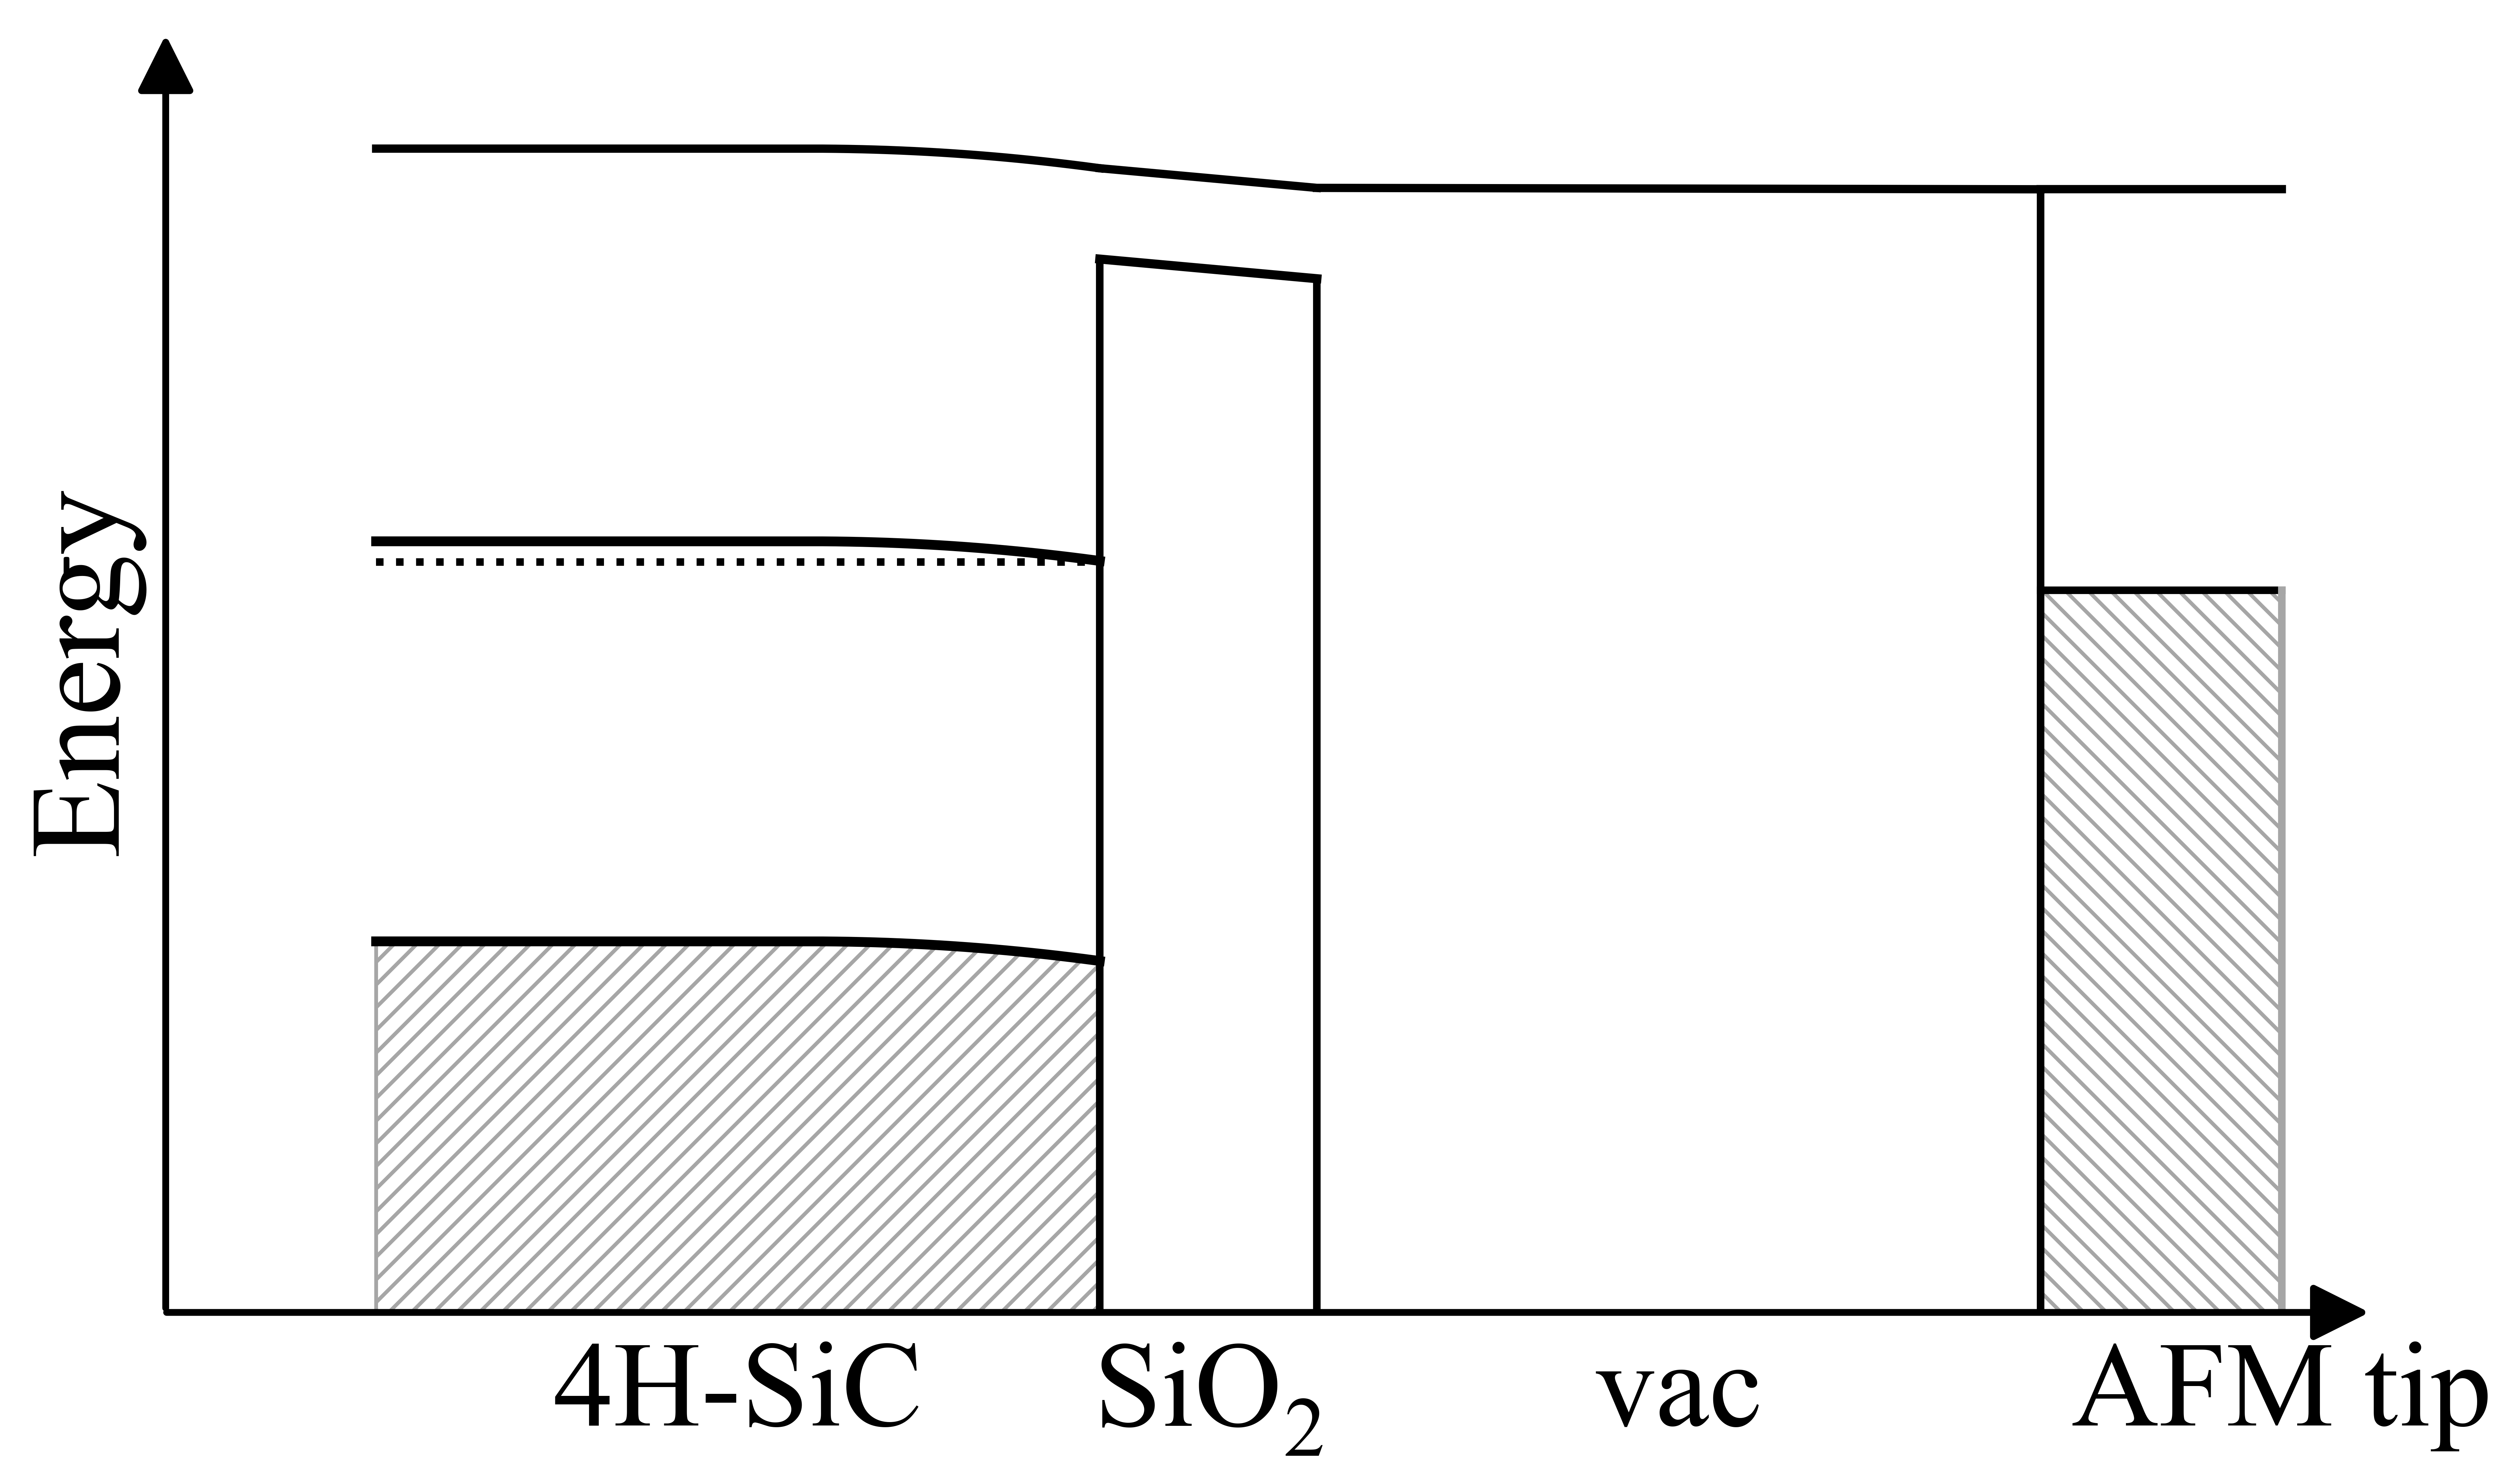

In [1]:
# -*- coding: utf-8 -*-
"""
Band diagram generator (vacuum level follows potential) with layout lock
- SiC/SiO2 側は据え置き、vacuum 厚さ (widths.gap) を変えると Tip のみ左へスライド
- 画像サイズ・全体スケールは不変（lock_layout + layout_gap_ref）
- 修正:
  * 真空中 Evac の取り扱いを更新：チップ側プラトーは s に対して単調減少する結合係数 η(s) で決定
    （series 近似: η=1/(1+ε_ox*s/t_ox)、または exp 近似）
  * x軸↔y軸の原点微調整 / 端の描画切れ対策（従来通り）
"""

from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib import rcParams

# ---- Fonts ----
rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
    "mathtext.sf": "Times New Roman",
    "mathtext.tt": "Times New Roman",
    "mathtext.cal": "Times New Roman",
    "axes.unicode_minus": False,
})

# ======================= 1) Data models =======================

@dataclass
class TrapLevel:
    energy_eV: float
    label: str = ""
    region: str = "interface"   # "sic" | "oxide" | "interface" | "tip"
    x_offset: float = 0.0
    marker_size: int = 90

@dataclass
class BandBending:
    delta_Ec_surface_eV: float = 0.0
    delta_Ev_surface_eV: float = 0.0
    curvature: float = 2.0
    use_exponential: bool = False
    lambda_len: float = 0.35

@dataclass
class RegionWidths:
    sic: float = 4.0
    oxide: float = 1.0
    gap: float = 2.0     # ← 小さくすると Tip が左へ寄る（レイアウトは固定）
    tip: float = 1.35

@dataclass
class LabelOffsets:
    Ec_tag: Tuple[float, float] = (0.06,  0.02)
    Ev_tag: Tuple[float, float] = (0.06, -0.04)
    Ef_tag: Tuple[float, float] = (0.06,  0.02)
    Evac_dy: float = -0.03

@dataclass
class ArrowOptions:
    enabled: bool = False
    sic_bandgap: bool = True
    sic_workfunc: bool = True
    tip_workfunc: bool = True
    oxide_barrier_Ec: bool = False
    text_dx_frac: float = 0.015
    lw: float = 1.6

@dataclass
class AxesArrowOptions:
    enabled: bool = True
    lw: float = 1.8
    head_width_pts: float = 8.0
    head_length_pts: float = 10.0
    # 原点（x軸とy軸の交点）微調整（全体幅・高さに対する割合）
    origin_shift_frac: Tuple[float, float] = (0.0, 0.0)
    # 端のはみ出し（描画切れ防止）
    x_overshoot_frac: float = 0.0
    y_overshoot_frac: float = 0.0

@dataclass
class DiagramConfig:
    # Energies (eV)
    Ev_bulk_eV: float
    Ec_bulk_eV: float
    Ef_sic_eV: float
    Ef_tip_eV: float
    Evac_eV: float

    # Plot range
    y_min_eV: float = 0.0
    y_max_eV: float = 6.0

    # Geometry
    widths: RegionWidths = field(default_factory=RegionWidths)
    show_oxide: bool = True

    # SiO2 upper edge model (linear follow)
    oxide_top_eV: Optional[float] = None
    oxide_follow_scale: float = 1.0
    # 互換性のための名残（内部では使用しない）
    vacuum_follow_scale: float = 0.0

    # SiC band bending
    bending: BandBending = field(default_factory=BandBending)

    # Traps
    traps: List[TrapLevel] = field(default_factory=list)
    show_traps: bool = True

    # Style
    show_level_tags: bool = True
    label_offsets: LabelOffsets = field(default_factory=LabelOffsets)
    show_hatch_semifilled: bool = True
    figsize: Tuple[float, float] = (12.0, 6.2)
    dpi: int = 160
    fontsize: int = 16

    # Region labels
    region_label_sic: str = "4H-SiC"
    region_label_oxide: str = "SiO$_2$"
    region_label_vac: str = "Vac"
    region_label_tip: str = "Tip"
    region_label_y: float = 0.02

    # Colors
    colors: Optional[Dict[str, str]] = None

    # Output
    output_path: Optional[object] = None  # None/False→no save, True/"auto"→timestamp, str→path

    # SiC region start & curve start
    sic_x_start: float = 0.0
    sic_curve_start_frac: float = 0.0

    # Design tweaks
    ef_sic_extend_left_frac: float = 0.08
    left_blank_frac: float = 0.40

    # Axis arrows
    axes_arrow: AxesArrowOptions = field(default_factory=AxesArrowOptions)

    # --- 固定レイアウト（全体幅ロック） ---
    lock_layout: bool = True
    layout_gap_ref: Optional[float] = None   # 例: 基準 3.0。Noneなら現行 widths.gap を採用
    layout_margin_frac: float = 0.05         # 左右マージン（全体幅に対する割合）

    # --- NEW: 真空結合モデル ---
    eps_oxide_rel: float = 3.9      # ε_ox/ε0
    vacuum_model: str = "series"    # "series" or "exp"
    vacuum_L0: float = 1.0          # exp モデル用（図の横スケールと同じ単位）
    vacuum_coupling_scale: float = 1.0  # |ΔEc_surface| に掛ける係数

# ======================= 2) Utilities =======================

def _C(cfg: DiagramConfig, key: str, default_gray: str) -> str:
    return (cfg.colors or {}).get(key, default_gray)

def _shape_value(t: np.ndarray, curv: float, use_exp: bool, L: float) -> np.ndarray:
    t = np.clip(t, 0.0, 1.0)
    if use_exp:
        L = max(1e-9, L)
        s = 1.0 - np.exp(-t / L)
        s /= (1.0 - np.exp(-1.0 / L))
        return s
    return t ** max(1.0, curv)

def _sic_bands(cfg: DiagramConfig, xs: np.ndarray, L: float):
    x_local = xs - xs[0]
    start_local = np.clip(cfg.sic_curve_start_frac, 0.0, 1.0) * L
    if L <= 1e-12 or start_local >= L:
        s = np.zeros_like(xs)
    else:
        u = (x_local - start_local) / max(1e-12, (L - start_local))
        u = np.clip(u, 0.0, 1.0)
        s = _shape_value(u, cfg.bending.curvature, cfg.bending.use_exponential, cfg.bending.lambda_len)
        s[x_local < start_local] = 0.0
    Ec = cfg.Ec_bulk_eV + cfg.bending.delta_Ec_surface_eV * s
    Ev = cfg.Ev_bulk_eV + cfg.bending.delta_Ev_surface_eV * s
    return Ec, Ev

def _sic_shift_at_x(x: float, x0: float, L: float, cfg: DiagramConfig) -> float:
    start_local = np.clip(cfg.sic_curve_start_frac, 0.0, 1.0) * L
    if L <= 1e-12 or start_local >= L:
        return 0.0
    u = ((x - x0) - start_local) / max(1e-12, (L - start_local))
    u = float(np.clip(u, 0.0, 1.0))
    s = float(_shape_value(np.array([u]), cfg.bending.curvature,
                           cfg.bending.use_exponential, cfg.bending.lambda_len)[0])
    return cfg.bending.delta_Ec_surface_eV * s

def _oxide_Ec(cfg: DiagramConfig, x_local: np.ndarray, Lox: float):
    base = cfg.oxide_top_eV
    if base is None:
        base = min(cfg.Evac_eV - 0.3, cfg.y_max_eV * 0.90)
    if Lox <= 1e-12:
        return np.full_like(x_local, fill_value=base)
    s_lin = np.clip(x_local / Lox, 0.0, 1.0)
    Ec_ox = base + cfg.oxide_follow_scale * abs(cfg.bending.delta_Ec_surface_eV) * s_lin
    return np.minimum(Ec_ox, cfg.Evac_eV - 1e-6)

def _auto_filename(prefix: str = "band_diagram", ext: str = "png") -> str:
    return f"{prefix}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.{ext}"

def _v_double_arrow(ax, x, y0, y1, text, text_dx, lw=1.6, color="0.0", z=12):
    ax.annotate("", xy=(x, y0), xytext=(x, y1),
                arrowprops=dict(arrowstyle="<->", color=color, lw=lw),
                zorder=z, clip_on=False)
    ax.text(x + text_dx, 0.5*(y0+y1), text, va="center", ha="left", zorder=z+1)

def _draw_axis_arrows(ax, xmin, xmax, ymin, ymax, opts: AxesArrowOptions):
    """x→, y↑ の軸矢印。原点の微調整と端のはみ出しをサポート。"""
    xr = (xmax - xmin)
    yr = (ymax - ymin)
    ox = xmin + opts.origin_shift_frac[0] * xr
    oy = ymin + opts.origin_shift_frac[1] * yr
    x_start = xmin - opts.x_overshoot_frac * xr
    x_end   = xmax + opts.x_overshoot_frac * xr
    y_start = ymin - opts.y_overshoot_frac * yr
    y_end   = ymax + opts.y_overshoot_frac * yr

    ax.annotate("",
        xy=(x_end, oy), xytext=(x_start, oy),
        arrowprops=dict(arrowstyle="-|>", lw=opts.lw, color="0.0"),
        clip_on=False)
    ax.annotate("",
        xy=(ox, y_end), xytext=(ox, y_start),
        arrowprops=dict(arrowstyle="-|>", lw=opts.lw, color="0.0"),
        clip_on=False)

# ---- NEW: coupling factor in vacuum ----
def _eta_gap(cfg: DiagramConfig, w: RegionWidths) -> float:
    """チップ側 Evac プラトーの結合係数 η(s)。0→遠距離、1→最強結合。"""
    s = max(0.0, float(w.gap))
    if s <= 1e-12:
        return 1.0
    if cfg.vacuum_model.lower() == "exp":
        L0 = max(1e-9, float(cfg.vacuum_L0))
        eta = np.exp(-s / L0)
    else:
        # series-capacitor-like: η = 1/(1 + ε_ox * s / t_ox)
        t_ox = max(1e-9, float(w.oxide if w.oxide > 0.0 else 1.0))
        eta = 1.0 / (1.0 + cfg.eps_oxide_rel * s / t_ox)
    return float(np.clip(eta, 0.0, 1.0))

# ======================= 3) Main draw =======================

def draw_band_diagram(cfg: DiagramConfig):
    plt.rcParams.update({
        "font.size": cfg.fontsize,
        "axes.titlesize": cfg.fontsize + 2,
        "axes.labelsize": cfg.fontsize + 2,
        "xtick.labelsize": cfg.fontsize,
        "ytick.labelsize": cfg.fontsize,
    })

    # --- Current positions from *current* widths ---
    w = cfg.widths
    x0 = cfg.sic_x_start
    x1 = x0 + w.sic
    x2 = x1 + (w.oxide if cfg.show_oxide else 0.0)
    x3 = x2 + w.gap
    x4 = x3 + w.tip

    # --- Layout (locked) width computed from reference gap ---
    layout_gap = (cfg.layout_gap_ref if (cfg.lock_layout and cfg.layout_gap_ref is not None)
                  else w.gap)
    layout_total_w = w.sic + (w.oxide if cfg.show_oxide else 0.0) + layout_gap + w.tip
    x_right_layout = x0 + layout_total_w

    # --- Start figure ---
    fig, ax = plt.subplots(figsize=cfg.figsize, dpi=cfg.dpi)
    fig.subplots_adjust(bottom=0.22)

    # --- SiC bands ---
    xs_sic = np.linspace(x1 - w.sic, x1, 500)  # ensure starts at x0
    Ec_sic, Ev_sic = _sic_bands(cfg, xs_sic, w.sic)

    # SiC E_F extend to left
    ef_dx = cfg.ef_sic_extend_left_frac * (x1 - x0)
    x_ef_left = x0 - ef_dx

    ax.plot(xs_sic, Ec_sic, linewidth=2.6, color=_C(cfg, "Ec_sic", "0.00"))
    ax.plot(xs_sic, Ev_sic, linewidth=2.6, color=_C(cfg, "Ev_sic", "0.00"))
    ax.plot([x_ef_left, x1], [cfg.Ef_sic_eV, cfg.Ef_sic_eV],
            linestyle=":", linewidth=2.0, color=_C(cfg, "Ef_sic", "0.00"))

    if cfg.show_level_tags:
        dx, dy = cfg.label_offsets.Ec_tag
        ax.text(x0 + dx*(x1-x0), Ec_sic[0] + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{C}$")
        dx, dy = cfg.label_offsets.Ev_tag
        ax.text(x0 + dx*(x1-x0), Ev_sic[0] + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{V}$")
        dx, dy = cfg.label_offsets.Ef_tag
        ax.text(x0 + dx*(x1-x0), cfg.Ef_sic_eV + dy*(cfg.y_max_eV-cfg.y_min_eV), r"$E_\mathrm{F}$")

    if cfg.show_hatch_semifilled:
        ax.fill_between(xs_sic, cfg.y_min_eV, Ev_sic,
                        hatch="////", facecolor="none",
                        edgecolor=_C(cfg, "hatch", "0.65"), zorder=1)

    # --- SiO2 ---
    if cfg.show_oxide and w.oxide > 0:
        xs_ox = np.linspace(x1, x2, 300)
        Ec_ox = _oxide_Ec(cfg, xs_ox - x1, w.oxide)
        ax.plot(xs_ox, Ec_ox, linewidth=2.4, color=_C(cfg, "Ec_oxide", "0.0"))
        ax.plot([x1, x1], [cfg.y_min_eV, Ec_ox[0]], linewidth=2.0, color=_C(cfg, "oxide_border", "0.0"))
        ax.plot([x2, x2], [cfg.y_min_eV, Ec_ox[-1]], linewidth=2.0, color=_C(cfg, "oxide_border", "0.0"))

    # --- Tip metal (from *current* x3,x4) ---
    ax.plot([x3, x4], [cfg.Ef_tip_eV, cfg.Ef_tip_eV], linewidth=2.0, color=_C(cfg, "Ef_tip", "0.0"))
    if cfg.show_hatch_semifilled:
        ax.fill_between([x3, x4], cfg.y_min_eV, [cfg.Ef_tip_eV, cfg.Ef_tip_eV],
                        step="pre", hatch="\\\\\\\\", facecolor="none", edgecolor=_C(cfg, "hatch", "0.65"))

    # --- Vacuum level Evac(x) ---
    Evac_sic = cfg.Evac_eV + (Ec_sic - cfg.Ec_bulk_eV)
    ax.plot(xs_sic, Evac_sic, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

    if cfg.show_oxide and w.oxide > 0:
        xs_ox = np.linspace(x1, x2, 300)
        s_lin_ox = (xs_ox - x1) / max(1e-12, (x2 - x1))
        Evac_ox = Evac_sic[-1] + cfg.oxide_follow_scale * abs(cfg.bending.delta_Ec_surface_eV) * s_lin_ox
        ax.plot(xs_ox, Evac_ox, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))
        Evac_right = Evac_ox[-1]
    else:
        Evac_right = Evac_sic[-1]

    # ---- NEW: vacuum gap with distance-dependent coupling ----
    # 結合符号は表面曲がりの符号に追随（ΔEc<0 なら Evac_tip は低くなる）
    bend_sign = 1.0 if cfg.bending.delta_Ec_surface_eV >= 0.0 else -1.0
    eta = _eta_gap(cfg, w)  # 0..1
    delta_tip = bend_sign * cfg.vacuum_coupling_scale * abs(cfg.bending.delta_Ec_surface_eV) * eta
    Evac_at_x3 = float(Evac_right + delta_tip)

    if w.gap > 0:
        xs_gap = np.linspace(x2, x3, 200)
        s_lin_gap = (xs_gap - x2) / max(1e-12, (x3 - x2))
        # x2→x3 を Evac_right→Evac_at_x3 に線形補間（連続性を担保）
        Evac_gap = (1.0 - s_lin_gap) * Evac_right + s_lin_gap * Evac_at_x3
        ax.plot(xs_gap, Evac_gap, linewidth=2.2, color=_C(cfg, "Evac", "0.00"))
    # tip borders & Evac (horizontal inside tip)
    ax.plot([x3, x3], [cfg.y_min_eV, Evac_at_x3], linewidth=2.0, color=_C(cfg, "tip_border", "0.0"))
    ax.plot([x4, x4], [cfg.y_min_eV, cfg.Ef_tip_eV], linewidth=2.0, color=_C(cfg, "tip_border", "0.65"))
    ax.plot([x3, x4], [Evac_at_x3, Evac_at_x3], linewidth=2.2, color=_C(cfg, "Evac", "0.00"))

    # --- Region labels ---
    y_axes = -cfg.region_label_y
    trans = ax.get_xaxis_transform()
    ax.text((x0+x1)/2, y_axes, cfg.region_label_sic, transform=trans, ha="center", va="top")
    if cfg.show_oxide and w.oxide > 0:
        ax.text((x1+x2)/2, y_axes, cfg.region_label_oxide, transform=trans, ha="center", va="top")
    ax.text((x2+x3)/2, y_axes, cfg.region_label_vac, transform=trans, ha="center", va="top")
    ax.text((x3+x4)/2 + 0.5, y_axes, cfg.region_label_tip, transform=trans, ha="center", va="top")

    # --- Traps ---
    if cfg.show_traps:
        layout_total_w = w.sic + (w.oxide if cfg.show_oxide else 0.0) + (cfg.layout_gap_ref if (cfg.lock_layout and cfg.layout_gap_ref is not None) else w.gap) + w.tip
        for tr in cfg.traps:
            if tr.region == "sic":
                x_tr = x0 + np.clip(tr.x_offset, 0.0, 1.0) * (x1 - x0)
                dE = _sic_shift_at_x(x_tr, x0, w.sic, cfg); Ef_ref = cfg.Ef_sic_eV
            elif tr.region == "interface":
                x_tr = x1; dE = _sic_shift_at_x(x_tr, x0, w.sic, cfg); Ef_ref = cfg.Ef_sic_eV
            elif tr.region == "oxide" and cfg.show_oxide and w.oxide > 0:
                x_tr = x1 + np.clip(tr.x_offset, 0.0, 1.0) * (x2 - x1)
                s_lin = float(np.clip((x_tr - x1) / max(1e-12, (x2 - x1)), 0.0, 1.0))
                dE = cfg.oxide_follow_scale * abs(cfg.bending.delta_Ec_surface_eV) * s_lin; Ef_ref = cfg.Ef_sic_eV
            elif tr.region == "tip":
                x_tr = x3 + np.clip(tr.x_offset, 0.0, 1.0) * (x4 - x3)
                dE = 0.0; Ef_ref = cfg.Ef_tip_eV
            else:
                continue

            y_tr = tr.energy_eV + dE
            fill_color = ('tab:blue' if y_tr > Ef_ref else 'tab:red')
            ax.scatter([x_tr], [y_tr], s=tr.marker_size, marker='o',
                       facecolors=fill_color, edgecolors='black', linewidths=1.2,
                       zorder=10, clip_on=False)
            if tr.label:
                ax.text(x_tr + 0.02*layout_total_w, y_tr, tr.label, va="center", zorder=11)

    # --- Cosmetics & axis arrows ---
    left_blank = cfg.left_blank_frac * (x1 - x0)
    xmin_candidates = [x0 - left_blank, x_ef_left - 0.02*(x_right_layout - x0), x0 - cfg.layout_margin_frac*(x_right_layout - x0)]
    xmin = min(xmin_candidates)
    xmax = x_right_layout + cfg.layout_margin_frac*(x_right_layout - x0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(cfg.y_min_eV, cfg.y_max_eV)
    ax.set_xlabel("")
    ax.set_ylabel("Energy")

    for s in ['top','right','bottom','left']:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    if cfg.axes_arrow.enabled:
        _draw_axis_arrows(ax, xmin, xmax, cfg.y_min_eV, cfg.y_max_eV, cfg.axes_arrow)

    fig.tight_layout()

    out = cfg.output_path
    if out is True or (isinstance(out, str) and str(out).lower() == "auto"):
        out = _auto_filename(prefix="band_diagram", ext="png")
    elif out in (None, False):
        out = None
    if isinstance(out, str) and out.strip():
        fig.savefig(out, bbox_inches="tight")
        print(f"[saved] {out}")
    return fig, ax

# ======================= 4) USER CONFIG =======================

if __name__ == "__main__":
    # --- 先に値を計算（自己参照バグ防止）---
    Ef_sic_val = 6.14
    phi_SiC = 3.37
    Evac_val = Ef_sic_val + phi_SiC
    phi_tip = 3.60
    Ef_tip_val = Evac_val - phi_tip
    oxide_top_val = Evac_val - 0.9

    cfg = DiagramConfig(
        Ev_bulk_eV = 3.05,
        Ec_bulk_eV = 6.31,
        Ef_sic_eV = Ef_sic_val,
        Ef_tip_eV = Ef_tip_val,
        Evac_eV   = Evac_val,

        y_min_eV = 0,
        y_max_eV = 10.5,

        widths = RegionWidths(sic=3.0, oxide=0.9, gap=3.0, tip=1.0),
        show_oxide = True,

        oxide_top_eV = oxide_top_val,
        oxide_follow_scale = -1.0,
        # vacuum_follow_scale は互換のため残すが内部で未使用
        vacuum_follow_scale = 0.0,

        bending = BandBending(
            delta_Ec_surface_eV = -0.16,
            delta_Ev_surface_eV = -0.16,
            curvature = 2.0,
            use_exponential = False,
            lambda_len = 0.35
        ),

        traps = [
            TrapLevel(energy_eV=6.43, label=r"$E^{it}_{1}$", region="interface"),
            # TrapLevel(energy_eV=6.23, label=r"$E^{it}_{2}$", region="interface"),
        ],
        show_traps = False,

        show_level_tags = False,
        figsize = (10.03, 6.2),
        dpi = 800,
        fontsize = 32,

        # デザイン
        ef_sic_extend_left_frac = 0.0,
        left_blank_frac = 0.30,

        # 軸矢印
        axes_arrow = AxesArrowOptions(
            enabled=True,
            lw=1.8,
            origin_shift_frac = (0.003, 0.0025),
            x_overshoot_frac = 0.00,
            y_overshoot_frac = 0.00
        ),

        # --- レイアウト固定 ---
        lock_layout = True,
        layout_gap_ref = 3.0,   # 基準ギャップ（この値で全体幅を固定）
        layout_margin_frac = 0.05,

        # --- NEW: 真空結合 ---
        eps_oxide_rel = 3.9,       # ε_ox/ε0
        vacuum_model = "series",    # "series" or "exp"
        vacuum_L0 = 1.2,            # exp を使う場合の減衰長（図の横スケール）
        vacuum_coupling_scale = 1.0,

        output_path = True,
        sic_x_start = 2.5,
        sic_curve_start_frac = 0.60,
    )

    # 例）ギャップを狭めて Tip を左へ寄せる（見た目の全体幅は不変）
    # cfg.widths.gap = 1.2

    draw_band_diagram(cfg)
    plt.show()
